# Final model traning for paper


In [1]:
# Set to true to run models with simple hyperparameters and fewer epochs for testing purposes
TESTING_FOREST_ARCHITECTURE = False

In [2]:
import pandas as pd
import sys
import os

sys.path.append("../model-experimentation/data-preprocessing")
import prepare_file

sys.path.pop()

# load data set
clean_dataset_file = "../Clean_NPFC-Test_Database_V2.csv"

if not os.path.isfile(clean_dataset_file):
    prepare_file.generate_prepared_file(clean_dataset_file)
df = pd.read_csv(clean_dataset_file)

relevant_columns = [
    "Subject_ID",
    "Timestamp",
    "Test_Time",
    "Task_Num",
    "Task_Time",
    "Task_Type",
    "Frame",
    "Task_Frame",
    "Selfreport_valence",
    "Selfreport_arousal",
    "Selfreport_focus",
    "Face_Detection",
    "resmasknet_anger_aligned",
    "resmasknet_disgust_aligned",
    "resmasknet_fear_aligned",
    "resmasknet_happiness_aligned",
    "resmasknet_sadness_aligned",
    "resmasknet_surprise_aligned",
    "resmasknet_neutral_aligned",
    "resmasknet_max_emotion_value",
    "Temperature_aligned",
    "EDA_aligned",
    "BVP_aligned",
    "HeadBandOn",
    "Delta_TP9",
    "Delta_AF7",
    "Delta_AF8",
    "Delta_TP10",
    "Theta_TP9",
    "Theta_AF7",
    "Theta_AF8",
    "Theta_TP10",
    "Alpha_TP9",
    "Alpha_AF7",
    "Alpha_AF8",
    "Alpha_TP10",
    "Beta_TP9",
    "Beta_AF7",
    "Beta_AF8",
    "Beta_TP10",
    "Gamma_TP9",
    "Gamma_AF7",
    "Gamma_AF8",
    "Gamma_TP10",
    "Gender",
    "Perceived_Tiredness",
    "Perceived_Stress",
    "Wearing_Glasses",
]

df = df[relevant_columns]

df.info()


<class 'pandas.DataFrame'>
RangeIndex: 22105 entries, 0 to 22104
Data columns (total 48 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Subject_ID                    22105 non-null  str    
 1   Timestamp                     22105 non-null  str    
 2   Test_Time                     22105 non-null  str    
 3   Task_Num                      22105 non-null  float64
 4   Task_Time                     22105 non-null  str    
 5   Task_Type                     22105 non-null  int64  
 6   Frame                         22105 non-null  int64  
 7   Task_Frame                    22105 non-null  int64  
 8   Selfreport_valence            22105 non-null  int64  
 9   Selfreport_arousal            22105 non-null  int64  
 10  Selfreport_focus              22105 non-null  int64  
 11  Face_Detection                22105 non-null  int64  
 12  resmasknet_anger_aligned      22105 non-null  float64
 13  resmasknet_d

In [3]:
# This is added because when testing with low iterations, some models throw convergence warnings, makes it impossible to see outputs
if TESTING_FOREST_ARCHITECTURE:
    import warnings

    warnings.filterwarnings("ignore")

# Random Forest model training


## Feature scaling and selection

Selecting the best features (X).
Also creating the features for prediction (Y).


In [4]:
# Select relevant features
feature_columns = [
    "Selfreport_valence",
    "Selfreport_arousal",
    "Selfreport_focus",
    "Temperature_aligned",
    "EDA_aligned",
    "BVP_aligned",
    "Delta_TP9",
    "Delta_AF7",
    "Delta_AF8",
    "Delta_TP10",
    "Theta_TP9",
    "Theta_AF7",
    "Theta_AF8",
    "Theta_TP10",
    "Alpha_TP9",
    "Alpha_AF7",
    "Alpha_AF8",
    "Alpha_TP10",
    "Beta_TP9",
    "Beta_AF7",
    "Beta_AF8",
    "Beta_TP10",
    "Gamma_TP9",
    "Gamma_AF7",
    "Gamma_AF8",
    "Gamma_TP10",
    "Gender",
    "Perceived_Tiredness",
    "Perceived_Stress",
    "Wearing_Glasses",
]

feature_df = df[feature_columns]

# Output the results of the feature selection
feature_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 22105 entries, 0 to 22104
Data columns (total 30 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Selfreport_valence   22105 non-null  int64  
 1   Selfreport_arousal   22105 non-null  int64  
 2   Selfreport_focus     22105 non-null  int64  
 3   Temperature_aligned  21774 non-null  float64
 4   EDA_aligned          21792 non-null  float64
 5   BVP_aligned          21767 non-null  float64
 6   Delta_TP9            22105 non-null  float64
 7   Delta_AF7            22105 non-null  float64
 8   Delta_AF8            22105 non-null  float64
 9   Delta_TP10           22105 non-null  float64
 10  Theta_TP9            22105 non-null  float64
 11  Theta_AF7            22105 non-null  float64
 12  Theta_AF8            22105 non-null  float64
 13  Theta_TP10           22105 non-null  float64
 14  Alpha_TP9            22105 non-null  float64
 15  Alpha_AF7            22105 non-null  float64
 1

In [7]:
### Data normalization preprocessor
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import RobustScaler, MinMaxScaler

# All physiological signals, brainwave bands, and temperature
sensor_and_eeg_features = [
    "Temperature_aligned",
    "EDA_aligned",
    "BVP_aligned",
    "Delta_TP9",
    "Delta_AF7",
    "Delta_AF8",
    "Delta_TP10",
    "Theta_TP9",
    "Theta_AF7",
    "Theta_AF8",
    "Theta_TP10",
    "Alpha_TP9",
    "Alpha_AF7",
    "Alpha_AF8",
    "Alpha_TP10",
    "Beta_TP9",
    "Beta_AF7",
    "Beta_AF8",
    "Beta_TP10",
    "Gamma_TP9",
    "Gamma_AF7",
    "Gamma_AF8",
    "Gamma_TP10",
]

# Subjective human ratings
survey_features = [
    "Selfreport_valence",
    "Selfreport_arousal",
    "Selfreport_focus",
    "Perceived_Tiredness",
    "Perceived_Stress",
]

# Metadata/Demographics left untouched
binary_features = ["Gender", "Wearing_Glasses"]

# Robust pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ("robust_sensors", RobustScaler(), sensor_and_eeg_features),
        ("minmax_survey", MinMaxScaler(), survey_features),
        ("pass_binary", "passthrough", binary_features),
    ]
)

# HOW TO USE:
# X_train_scaled = preprocessor.fit_transform(X_train)
# X_test_scaled = preprocessor.transform(X_test)

## Model creation and training

Here we are tranining the regression model. In particular, a random forest model. This model will predict the uncertainty of the resmasknet FER model.


In [6]:
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import RFECV
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# Convert all variables to float to ensure missing values are numpy safe (from pandas.NA to np.nan)
# and also filling any created NaN to avoid downstream scikit-learn estimator failures.
X = feature_df.astype(float).fillna(0)
y = df["resmasknet_max_emotion_value"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Apply preprocessor perfectly matching the comment block example
X_train_scaled = preprocessor.fit_transform(X_train)
X_test_scaled = preprocessor.transform(X_test)

# Extract generated feature names dynamically
feature_names_out = preprocessor.get_feature_names_out()


In [1]:
# --- Random Forest Regressor with RFE Backward Elimination ---
print("--- Random Forest Regressor ---")

if TESTING_FOREST_ARCHITECTURE:
    rf_reg = RandomForestRegressor(random_state=42, n_estimators=1, n_jobs=-1)
else:
    rf_reg = RandomForestRegressor(random_state=42, n_estimators=100, n_jobs=-1)

# RFECV performs recursive backward elimination and selected best features by CV score
rf_selector = RFECV(estimator=rf_reg, step=0.1, cv=3, scoring="neg_mean_squared_error")
rf_selector.fit(X_train_scaled, y_train)

X_train_rf = rf_selector.transform(X_train_scaled)
X_test_rf = rf_selector.transform(X_test_scaled)

rf_reg.fit(X_train_rf, y_train)
y_pred_rf = rf_reg.predict(X_test_rf)

print(f"Optimal number of features: {rf_selector.n_features_}")
print(f"Selected features: {feature_names_out[rf_selector.support_]}")

mse_rf = mean_squared_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)
mae_rf = mean_absolute_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)
n_rf = X_test_rf.shape[0]  # type: ignore
p_rf = X_test_rf.shape[1]  # type: ignore
adj_r2_rf = (
    1 - (1 - r2_rf) * (n_rf - 1) / (n_rf - p_rf - 1)
    if (n_rf - p_rf - 1) > 0
    else float("nan")
)

print(f"MSE: {mse_rf:.4f}")
print(f"RMSE: {rmse_rf:.4f}")
print(f"MAE: {mae_rf:.4f}")
print(f"R-squared: {r2_rf:.4f}")
print(f"Adjusted R-squared: {adj_r2_rf:.4f}\n")

--- Random Forest Regressor ---
Optimal number of features: 30
Selected features: ['robust_sensors__Temperature_aligned' 'robust_sensors__EDA_aligned'
 'robust_sensors__BVP_aligned' 'robust_sensors__Delta_TP9'
 'robust_sensors__Delta_AF7' 'robust_sensors__Delta_AF8'
 'robust_sensors__Delta_TP10' 'robust_sensors__Theta_TP9'
 'robust_sensors__Theta_AF7' 'robust_sensors__Theta_AF8'
 'robust_sensors__Theta_TP10' 'robust_sensors__Alpha_TP9'
 'robust_sensors__Alpha_AF7' 'robust_sensors__Alpha_AF8'
 'robust_sensors__Alpha_TP10' 'robust_sensors__Beta_TP9'
 'robust_sensors__Beta_AF7' 'robust_sensors__Beta_AF8'
 'robust_sensors__Beta_TP10' 'robust_sensors__Gamma_TP9'
 'robust_sensors__Gamma_AF7' 'robust_sensors__Gamma_AF8'
 'robust_sensors__Gamma_TP10' 'minmax_survey__Selfreport_valence'
 'minmax_survey__Selfreport_arousal' 'minmax_survey__Selfreport_focus'
 'minmax_survey__Perceived_Tiredness' 'minmax_survey__Perceived_Stress'
 'pass_binary__Gender' 'pass_binary__Wearing_Glasses']
MSE: 0.0159
R

## Feature importance extraction


In [8]:
selected_feature_names = feature_names_out[rf_selector.support_]

rf_importances = rf_reg.feature_importances_
rf_importance_df = pd.DataFrame(
    {"Feature": selected_feature_names, "Importance": rf_importances}
).sort_values(by="Importance", ascending=False)

print(rf_importance_df)

                                Feature  Importance
1           robust_sensors__EDA_aligned    0.105566
0   robust_sensors__Temperature_aligned    0.103390
21            robust_sensors__Gamma_AF8    0.065967
2           robust_sensors__BVP_aligned    0.045748
19            robust_sensors__Gamma_TP9    0.039883
26   minmax_survey__Perceived_Tiredness    0.036941
16             robust_sensors__Beta_AF7    0.036346
22           robust_sensors__Gamma_TP10    0.035846
11            robust_sensors__Alpha_TP9    0.032643
15             robust_sensors__Beta_TP9    0.032246
17             robust_sensors__Beta_AF8    0.032239
14           robust_sensors__Alpha_TP10    0.032064
18            robust_sensors__Beta_TP10    0.030949
3             robust_sensors__Delta_TP9    0.029402
7             robust_sensors__Theta_TP9    0.029199
4             robust_sensors__Delta_AF7    0.028345
6            robust_sensors__Delta_TP10    0.028219
10           robust_sensors__Theta_TP10    0.028075
20          

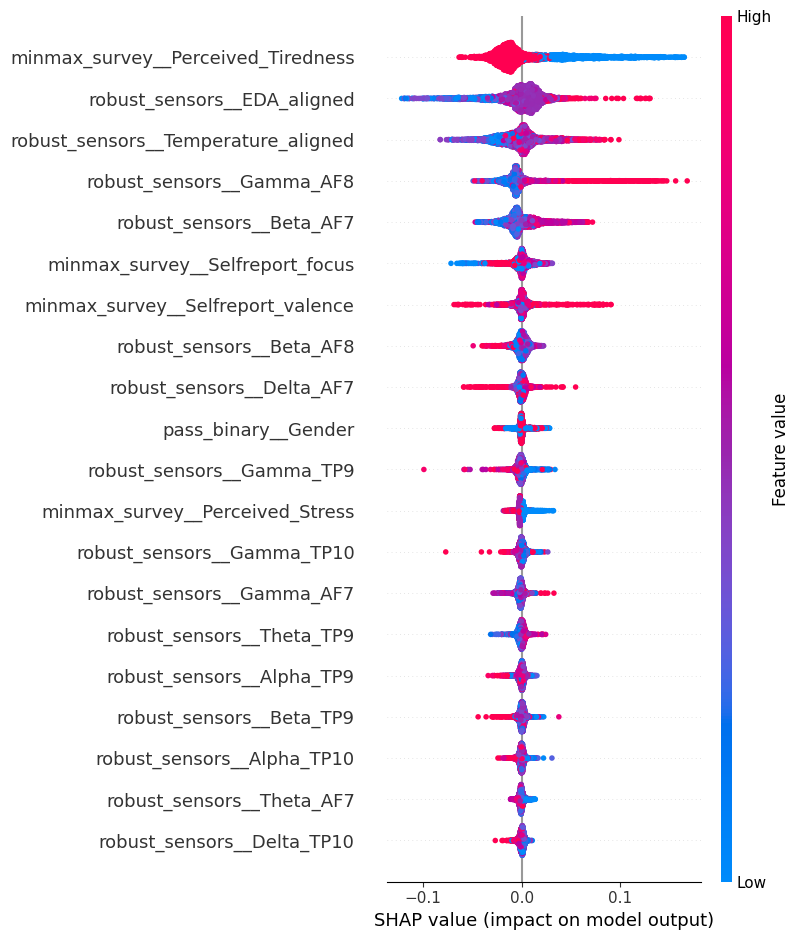

In [9]:
# SHAP (SHapley Additive exPlanations)
import shap

# 1. Summarize the background data so the explainer runs in seconds, not hours
background_data = shap.sample(X_train_rf, 50)

# 2. Create an explainer for the Random Forest model
# Note: We use X_train_rf because the model was trained on the reduced feature set
explainer = shap.TreeExplainer(rf_reg)

# 3. Calculate SHAP values for the test set
shap_values = explainer.shap_values(X_test_rf)

# 4. Plot the summary
# We pass the selected feature names so the plot is readable
shap.summary_plot(shap_values, X_test_rf, feature_names=selected_feature_names)

# Linear mixed model (LMM) training


## Feature scaling and selection


In [ ]:
# Select relevant features. For LMM we include Subject_ID and Task_Num as features to allow for random effects
feature_columns = [
    "Subject_ID",
    "Task_Num",
    "Selfreport_valence",
    "Selfreport_arousal",
    "Selfreport_focus",
    "Temperature_aligned",
    "EDA_aligned",
    "BVP_aligned",
    "Delta_TP9",
    "Delta_AF7",
    "Delta_AF8",
    "Delta_TP10",
    "Theta_TP9",
    "Theta_AF7",
    "Theta_AF8",
    "Theta_TP10",
    "Alpha_TP9",
    "Alpha_AF7",
    "Alpha_AF8",
    "Alpha_TP10",
    "Beta_TP9",
    "Beta_AF7",
    "Beta_AF8",
    "Beta_TP10",
    "Gamma_TP9",
    "Gamma_AF7",
    "Gamma_AF8",
    "Gamma_TP10",
    "Gender",
    "Perceived_Tiredness",
    "Perceived_Stress",
    "Wearing_Glasses",
]

lmm_df_with_nan = df[feature_columns + ["resmasknet_max_emotion_value"]]
lmm_df = lmm_df_with_nan.dropna()
lmm_df = lmm_df.rename(columns={"resmasknet_max_emotion_value": "certainty"})
result_column = ["certainty"]

In [9]:
# Renaming categorical values for easier presentation later
lmm_df["Perceived_Tiredness"] = (
    lmm_df["Perceived_Tiredness"]
    .astype(int)
    .map({0: "0_Not_tired", 1: "1_Slightly_tired", 2: "2_Moderately_tired"})
)

lmm_df["Perceived_Stress"] = (
    lmm_df["Perceived_Stress"]
    .astype(int)
    .map(
        {
            0: "0_Not_stressed",
            1: "1_Slightly_stressed",
            2: "2_Moderately_stressed",
            3: "3_Very_stressed",
        }
    )
)

lmm_df["Wearing_Glasses"] = (
    lmm_df["Wearing_Glasses"].astype(int).map({0: "0_No", 1: "1_Yes"})
)

lmm_df["Gender"] = lmm_df["Gender"].astype(int).map({0: "0_Male", 1: "1_Female"})

In [10]:
### Data normalization preprocessor

# All physiological signals, brainwave bands, and temperature
sensor_and_eeg_features = [
    "Temperature_aligned",
    "EDA_aligned",
    "BVP_aligned",
    "Delta_TP9",
    "Delta_AF7",
    "Delta_AF8",
    "Delta_TP10",
    "Theta_TP9",
    "Theta_AF7",
    "Theta_AF8",
    "Theta_TP10",
    "Alpha_TP9",
    "Alpha_AF7",
    "Alpha_AF8",
    "Alpha_TP10",
    "Beta_TP9",
    "Beta_AF7",
    "Beta_AF8",
    "Beta_TP10",
    "Gamma_TP9",
    "Gamma_AF7",
    "Gamma_AF8",
    "Gamma_TP10",
]

survey_features = [
    "Selfreport_valence",
    "Selfreport_arousal",
    "Selfreport_focus",
]

categorical_cols = [
    "Perceived_Tiredness",
    "Perceived_Stress",
    "Gender",
    "Wearing_Glasses",
    "Subject_ID",
    "Task_Num",
]

# Robust pipeline
preprocessor_lmm = ColumnTransformer(
    transformers=[
        ("robust_sensors", RobustScaler(), sensor_and_eeg_features),
        ("minmax_survey", MinMaxScaler(), survey_features),
        ("passthrough", "passthrough", categorical_cols + result_column),
    ],
    verbose_feature_names_out=False,
)
preprocessor_lmm.set_output(transform="pandas")

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('robust_sensors', ...), ('minmax_survey', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` an

In [11]:
import statsmodels.formula.api as smf
import scipy.stats as stats
import pandas as pd

train_lmm_df = preprocessor_lmm.fit_transform(lmm_df)

# Dynamically construct the formula string (predicting certainty)
categorical_features = [
    "Perceived_Tiredness",
    "Perceived_Stress",
    "Gender",
    "Wearing_Glasses",
]
numerical_features = sensor_and_eeg_features + survey_features
formatted_categorical_features = [f"C({col})" for col in categorical_features]

fixed_effects_formula = "certainty ~ " + " + ".join(
    numerical_features + formatted_categorical_features
)
print(fixed_effects_formula)


certainty ~ Temperature_aligned + EDA_aligned + BVP_aligned + Delta_TP9 + Delta_AF7 + Delta_AF8 + Delta_TP10 + Theta_TP9 + Theta_AF7 + Theta_AF8 + Theta_TP10 + Alpha_TP9 + Alpha_AF7 + Alpha_AF8 + Alpha_TP10 + Beta_TP9 + Beta_AF7 + Beta_AF8 + Beta_TP10 + Gamma_TP9 + Gamma_AF7 + Gamma_AF8 + Gamma_TP10 + Selfreport_valence + Selfreport_arousal + Selfreport_focus + C(Perceived_Tiredness) + C(Perceived_Stress) + C(Gender) + C(Wearing_Glasses)


In [12]:
# --- Linear Mixed-Effects Model Fit ---
print("--- Linear Mixed-Effects Model Fit ---")


lmm_model = smf.mixedlm(
    fixed_effects_formula,
    data=train_lmm_df,
    groups=train_lmm_df["Subject_ID"],
    vc_formula={"task_num": "0 + C(Task_Num)"},  # Use Task_Num as random effect
)
lmm_results = lmm_model.fit()
print(lmm_results.summary())

--- Linear Mixed-Effects Model Fit ---
                         Mixed Linear Model Regression Results
Model:                       MixedLM           Dependent Variable:           certainty 
No. Observations:            21242             Method:                       REML      
No. Groups:                  38                Scale:                        0.0164    
Min. group size:             16                Log-Likelihood:               12510.9952
Max. group size:             1233              Converged:                    Yes       
Mean group size:             559.0                                                     
---------------------------------------------------------------------------------------
                                             Coef.  Std.Err.   z    P>|z| [0.025 0.975]
---------------------------------------------------------------------------------------
Intercept                                     0.748    0.014 54.573 0.000  0.721  0.774
C(Perceived_Tiredn

/Users/sergiogzz/LocalDocs/GitHub/FER-Study/.venv/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


In [13]:
# --- Statistical Assumption Verification ---
print("--- Validation of LMM Residuals ---")

model_residuals = lmm_results.resid

# Check residual normality (sampled to 5000 if dataset size is large for Shapiro test scalability)
if len(model_residuals) > 5000:
    shapiro_sample = model_residuals.sample(5000, random_state=42)
    stat, p_value = stats.shapiro(shapiro_sample)
    print(
        f"Shapiro-Wilk Test (Sampled N=5000) - Statistic: {stat:.4f}, p-value: {p_value:.4e}"
    )
else:
    stat, p_value = stats.shapiro(model_residuals)
    print(f"Shapiro-Wilk Test - Statistic: {stat:.4f}, p-value: {p_value:.4e}")

print(f"Residuals Skewness: {stats.skew(model_residuals):.4f}")
print(f"Residuals Kurtosis: {stats.kurtosis(model_residuals):.4f}")

--- Validation of LMM Residuals ---
Shapiro-Wilk Test (Sampled N=5000) - Statistic: 0.9960, p-value: 2.0528e-10
Residuals Skewness: -0.2039
Residuals Kurtosis: -0.0495


# Final Figure Generation for Results Section

Creating composite figures combining Random Forest predictive power (SHAP)
and LMM structural explanation (Forest/Caterpillar plots).


In [14]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import shap
import statsmodels.api as sm

# Set publication-quality style parameters

plt.rcParams.update(
    {
        "font.size": 12,
        "axes.labelsize": 12,
        "axes.titlesize": 14,
        "xtick.labelsize": 10,
        "ytick.labelsize": 10,
        "legend.fontsize": 10,
        "figure.dpi": 300,  # High resolution for paper
        "savefig.bbox": "tight",
        "figure.figsize": (6, 4),  # (Width, Height in inches)
    }
)

### Figure 1: The Predictive and Explanatory Front (Global Effects)

Note: Because SHAP uses its own complex matplotlib rendering, it's safer to save it
as a standalone panel rather than trying to force it into a complex subplot layout.


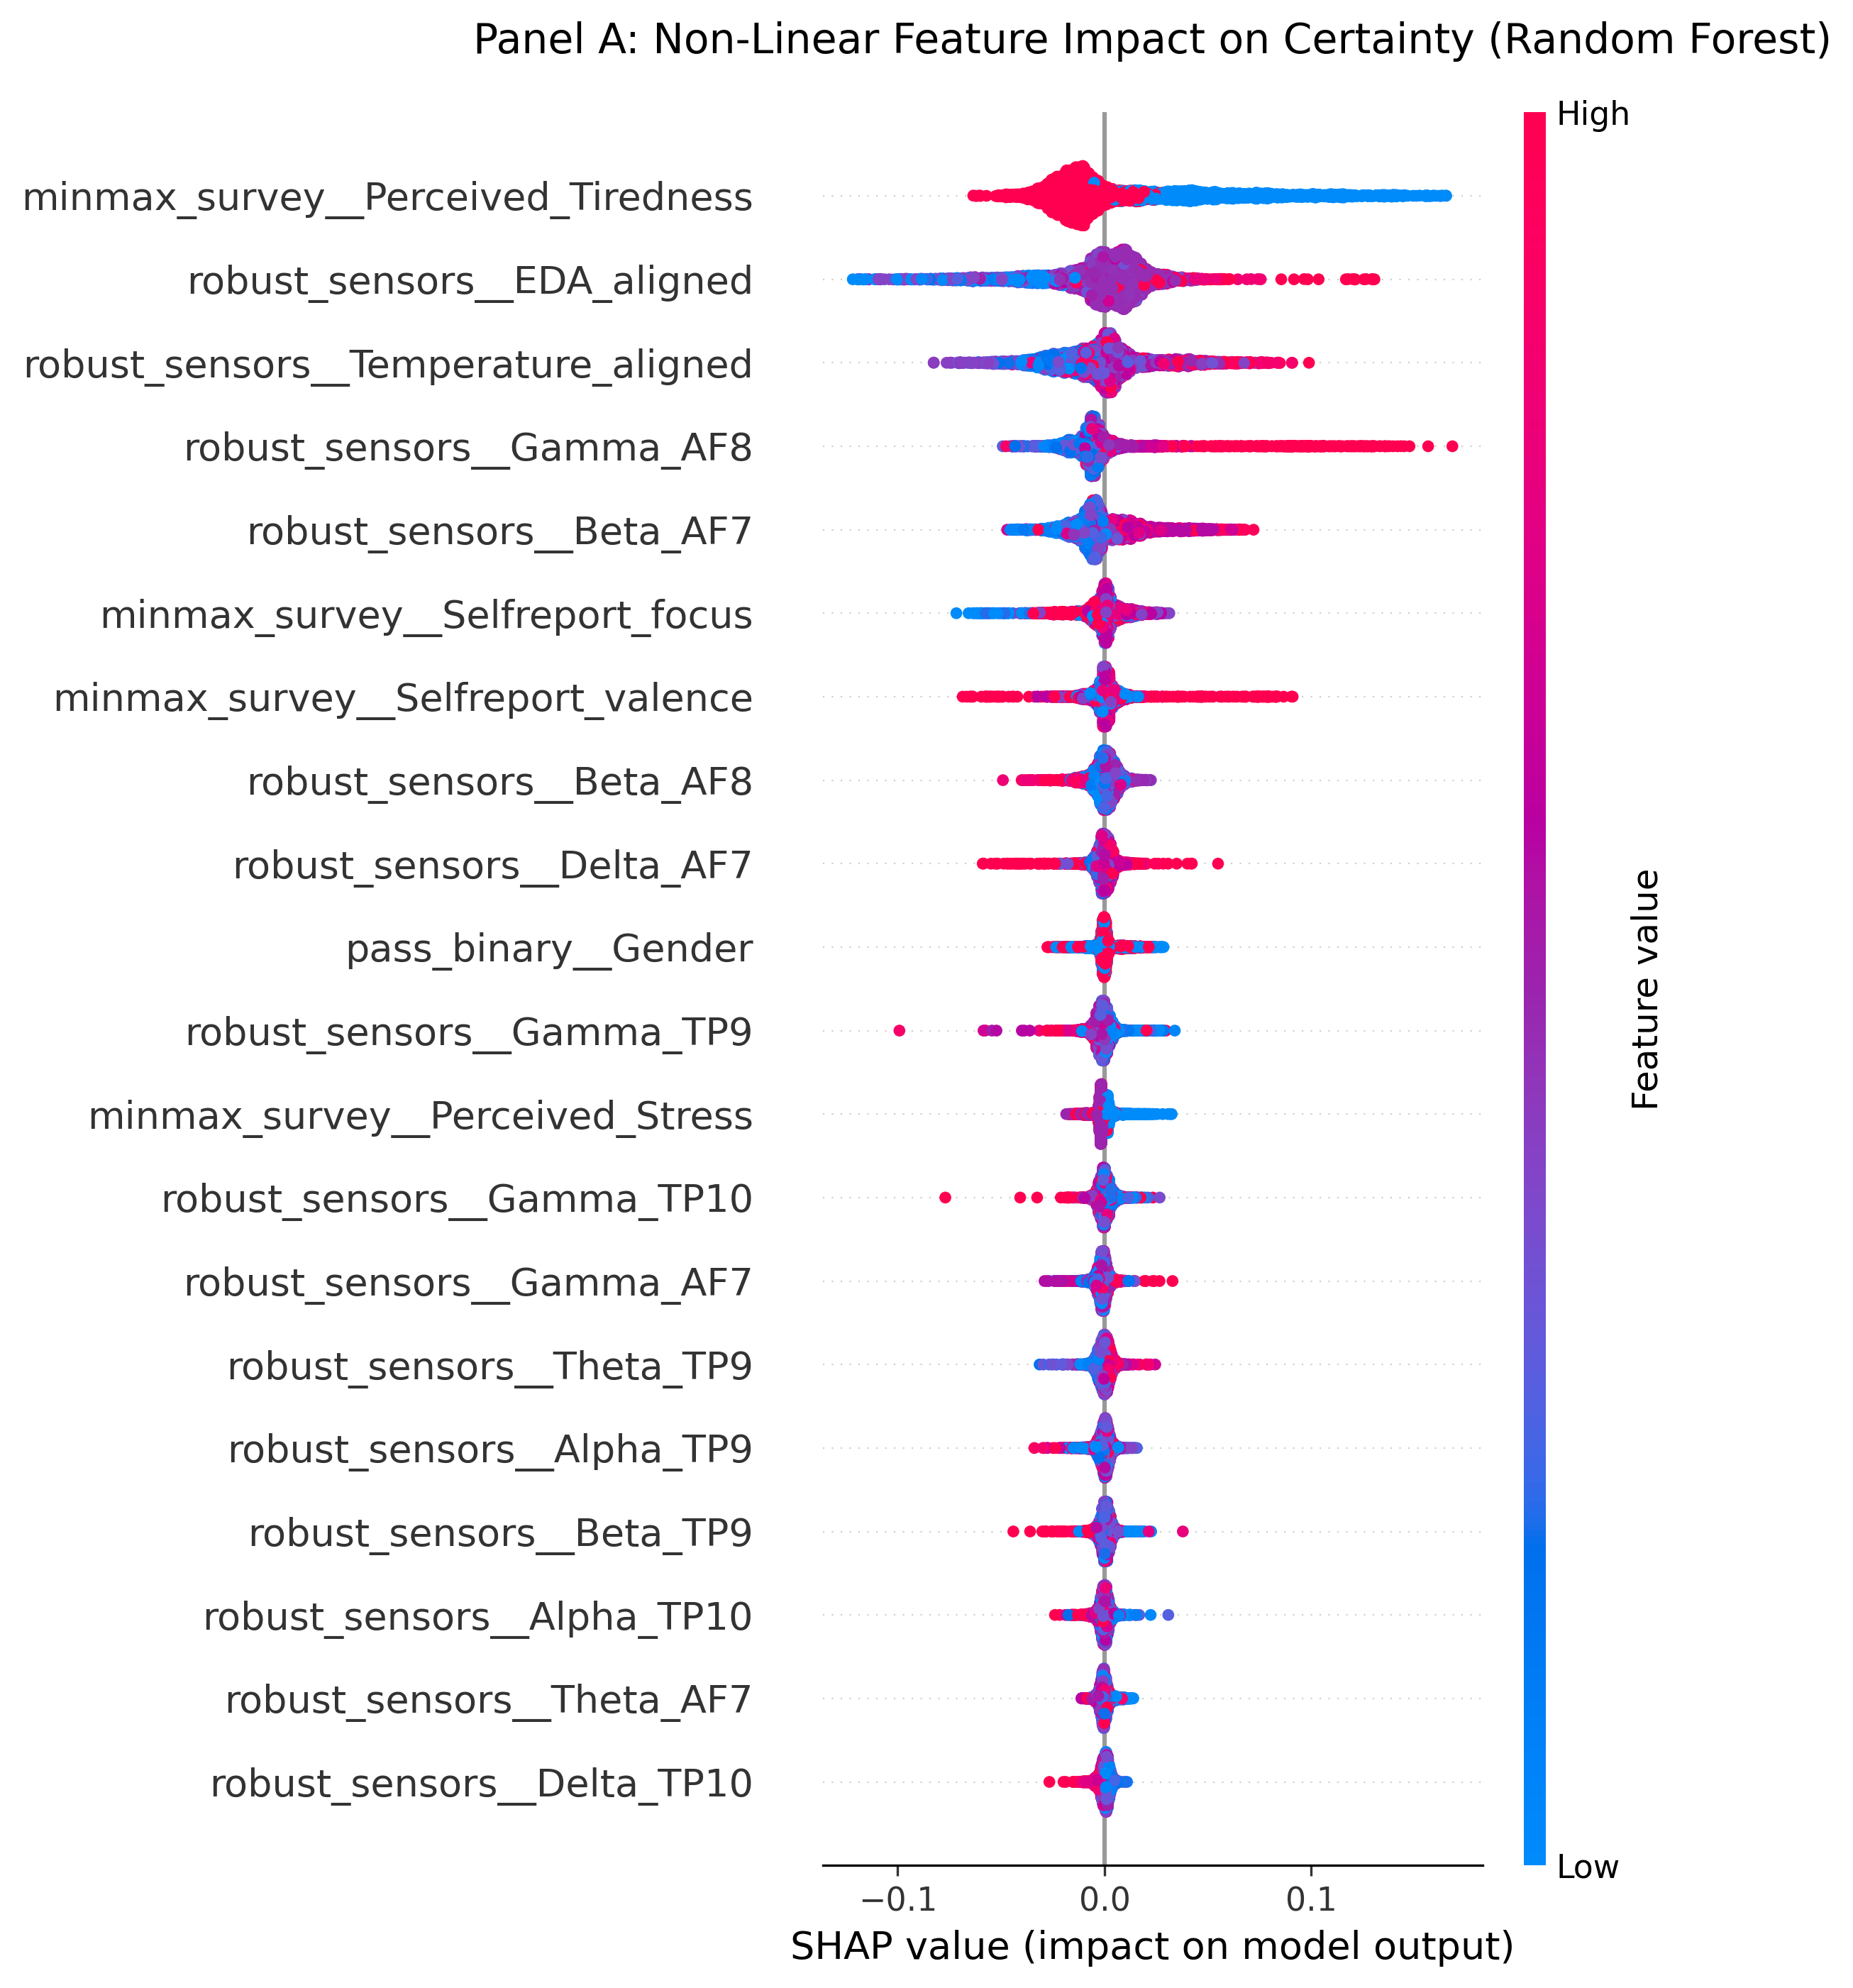

In [ ]:
# ==========================================
# PANEL A: SHAP Summary Plot (Random Forest)
# ==========================================
# Calculate SHAP values (assuming explainer and X_test_rf are in memory from previous cells)
shap_values = explainer.shap_values(X_test_rf)

plt.figure(figsize=(10, 8))
plt.title("Panel A: Non-Linear Feature Impact on Certainty (Random Forest)", pad=20)
# Force matplotlib backend for saving
shap.summary_plot(
    shap_values, X_test_rf, feature_names=selected_feature_names, show=False
)

plt.savefig("figures/Fig1_PanelA_SHAP.png")
plt.show()
plt.close()

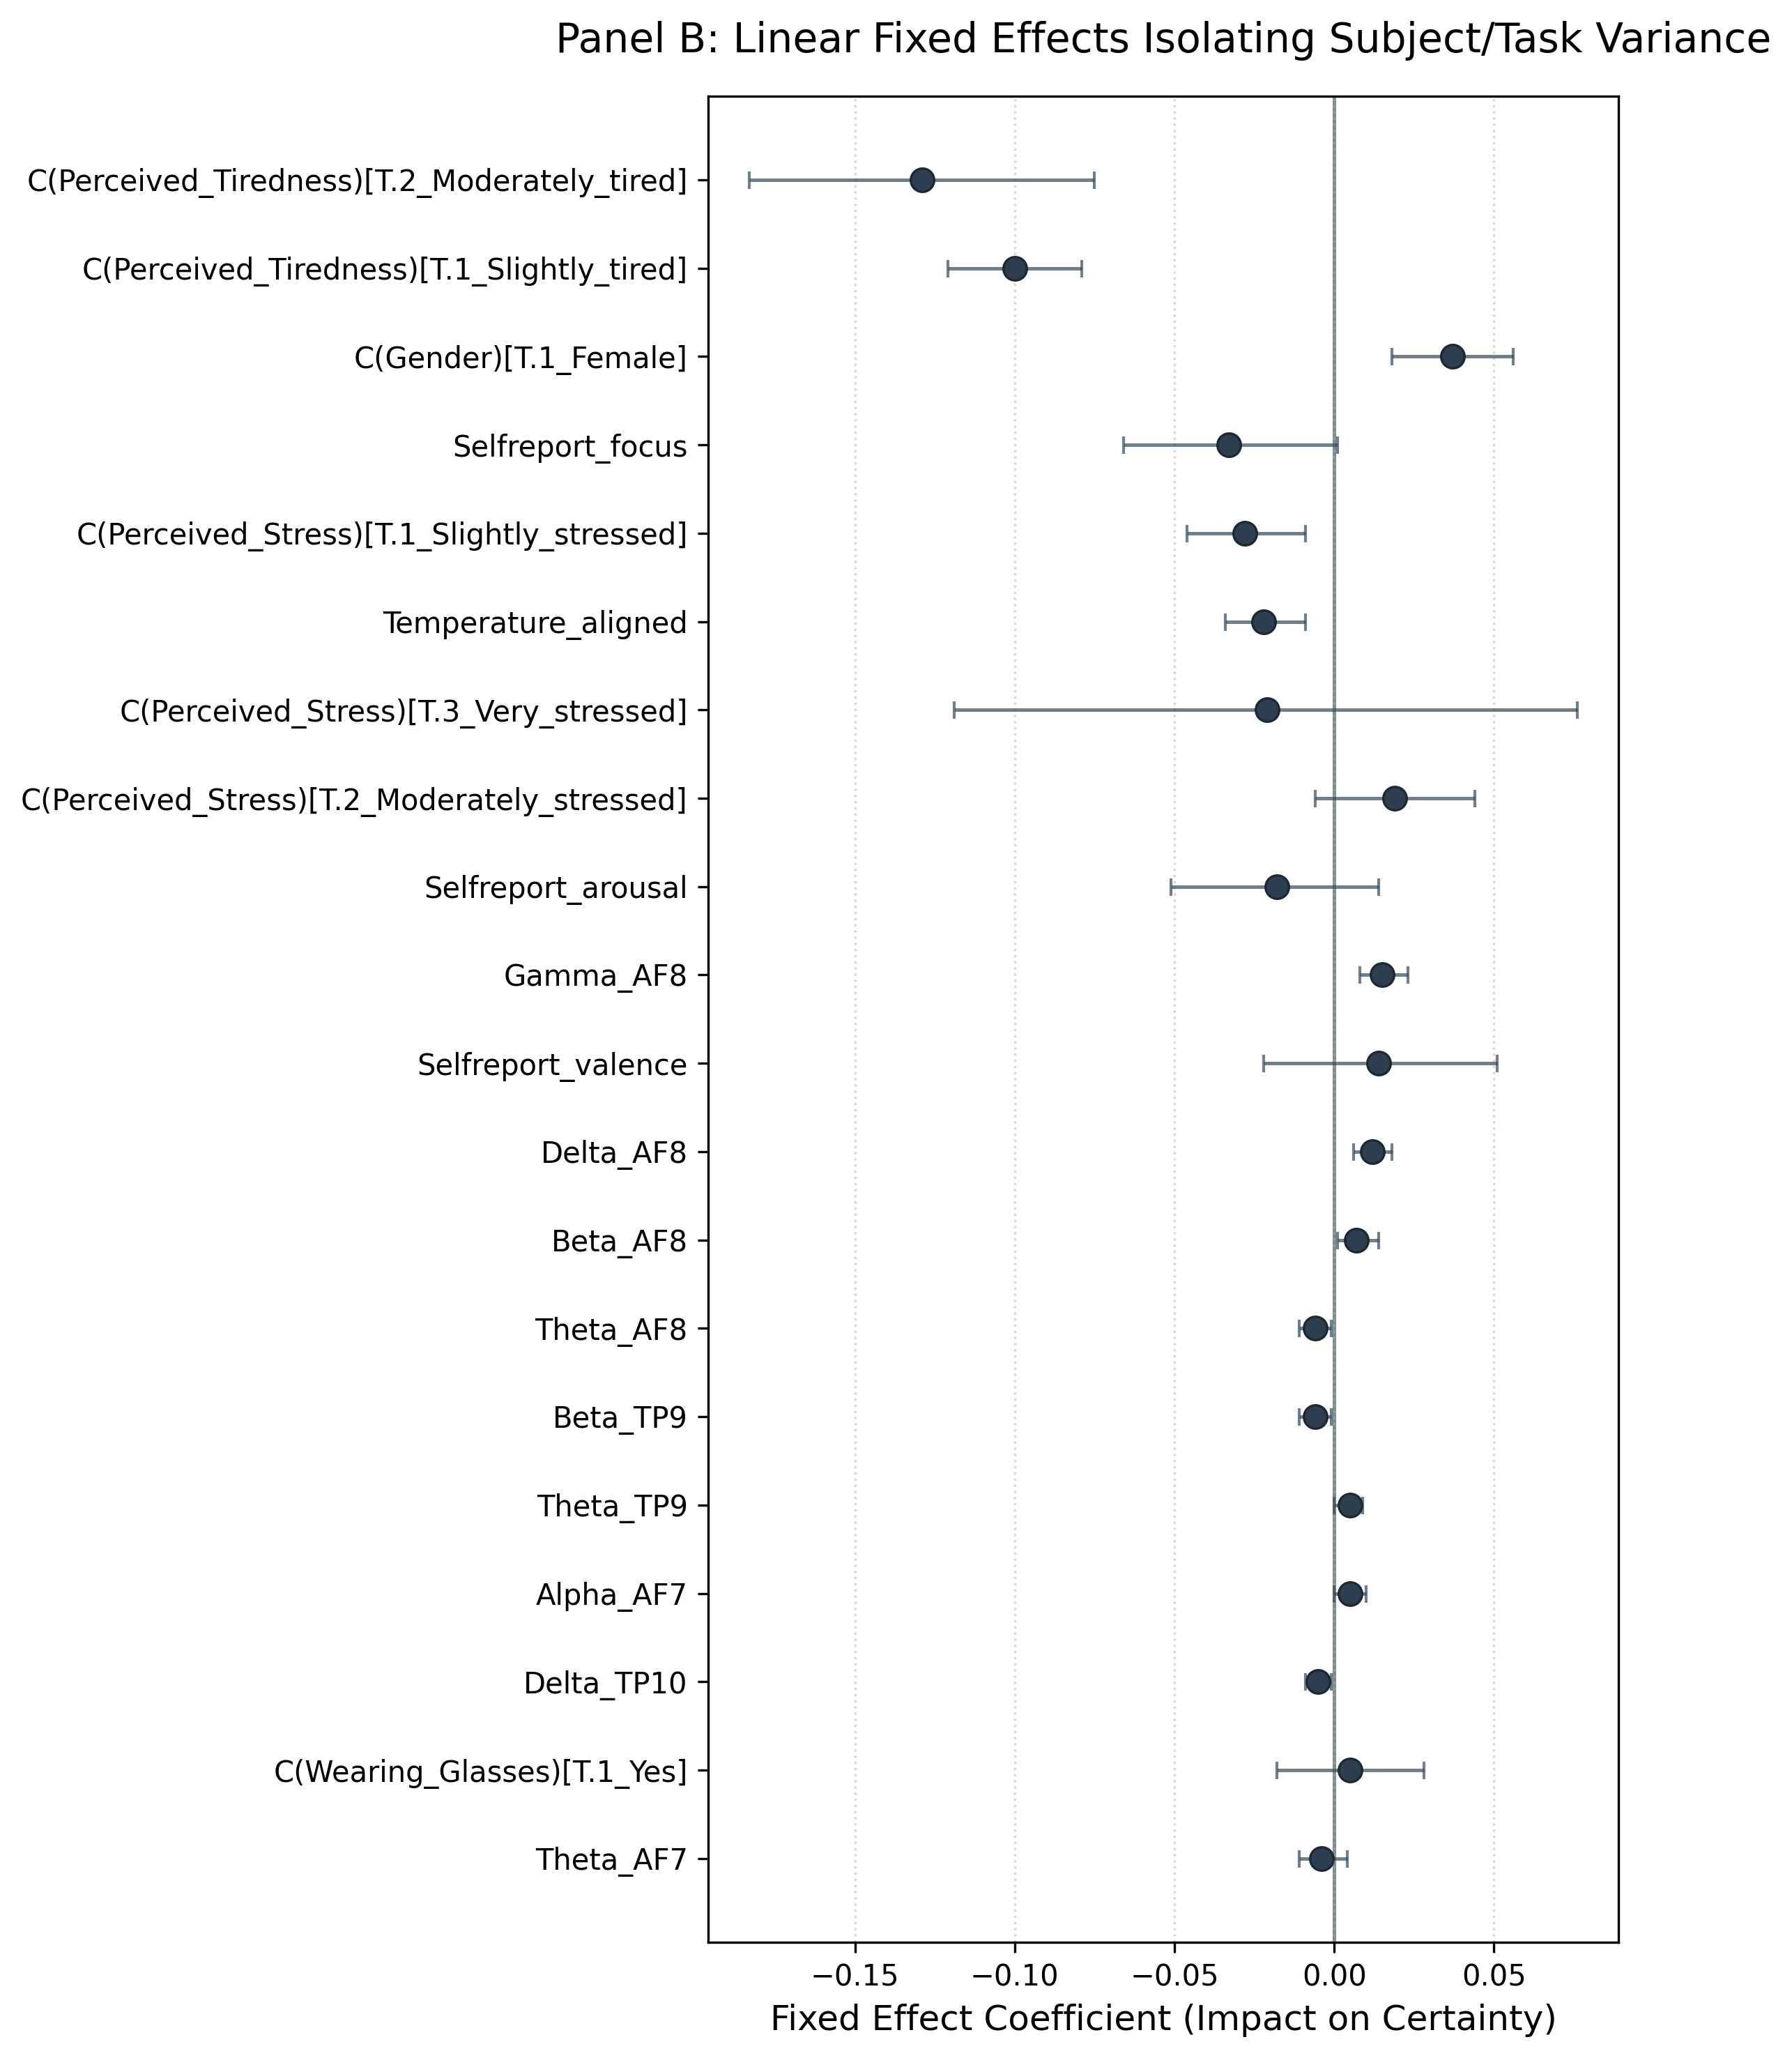

In [23]:
# ==========================================
# PANEL B: Forest Plot of Fixed Effects (LMM)
# ==========================================
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Extract coefficients from the LMM summary table (already a DataFrame for MixedLM)
coef_df = lmm_results.summary().tables[1].copy()
coef_df.columns = ["Coef", "StdErr", "z", "P>|z|", "CI_Lower", "CI_Upper"]

# Convert to numeric values and drop tracking artifacts
coef_df = coef_df.apply(pd.to_numeric, errors="coerce").dropna()

if "Intercept" in coef_df.index:
    coef_df = coef_df.drop("Intercept")

# Filter out any random variance component rows
coef_df = coef_df[~coef_df.index.str.contains("Var")]

# Sort by absolute coefficient size to maintain scannability
coef_df["abs_coef"] = coef_df["Coef"].abs()
coef_df = coef_df.sort_values(by="abs_coef", ascending=True)

# Select top 20 features to prevent vertical crowding
coef_df = coef_df.tail(20)

# Plot Initialization
fig, ax = plt.subplots(figsize=(8, 10))
y_pos = np.arange(len(coef_df))

# 1. Solid vertical baseline anchor
ax.axvline(x=0, color="#7f8c8d", linestyle="-", linewidth=1.2, zorder=1)

# 2. Clean, high-contrast horizontal confidence intervals
ax.errorbar(
    coef_df["Coef"],
    y_pos,
    xerr=[coef_df["Coef"] - coef_df["CI_Lower"], coef_df["CI_Upper"] - coef_df["Coef"]],
    fmt="none",
    ecolor="#34495e",
    capsize=3,
    elinewidth=1.2,
    alpha=0.7,
    zorder=2,
)

# 3. Standardized dark slate markers
ax.scatter(
    coef_df["Coef"],
    y_pos,
    color="#2c3e50",
    s=65,
    edgecolors="#1c2833",
    linewidths=0.8,
    zorder=3,
)

# Formatting
ax.set_yticks(y_pos)
ax.set_yticklabels(coef_df.index)
ax.set_xlabel("Fixed Effect Coefficient (Impact on Certainty)")
ax.set_title("Panel B: Linear Fixed Effects Isolating Subject/Task Variance", pad=15)
ax.grid(axis="x", linestyle=":", alpha=0.5, zorder=0)

plt.tight_layout()
plt.savefig("figures/Fig1_PanelB_LMM_Forest.png")
plt.show()
plt.close()

### Figure 2: The Impact of Context (Crossed Random Effects)


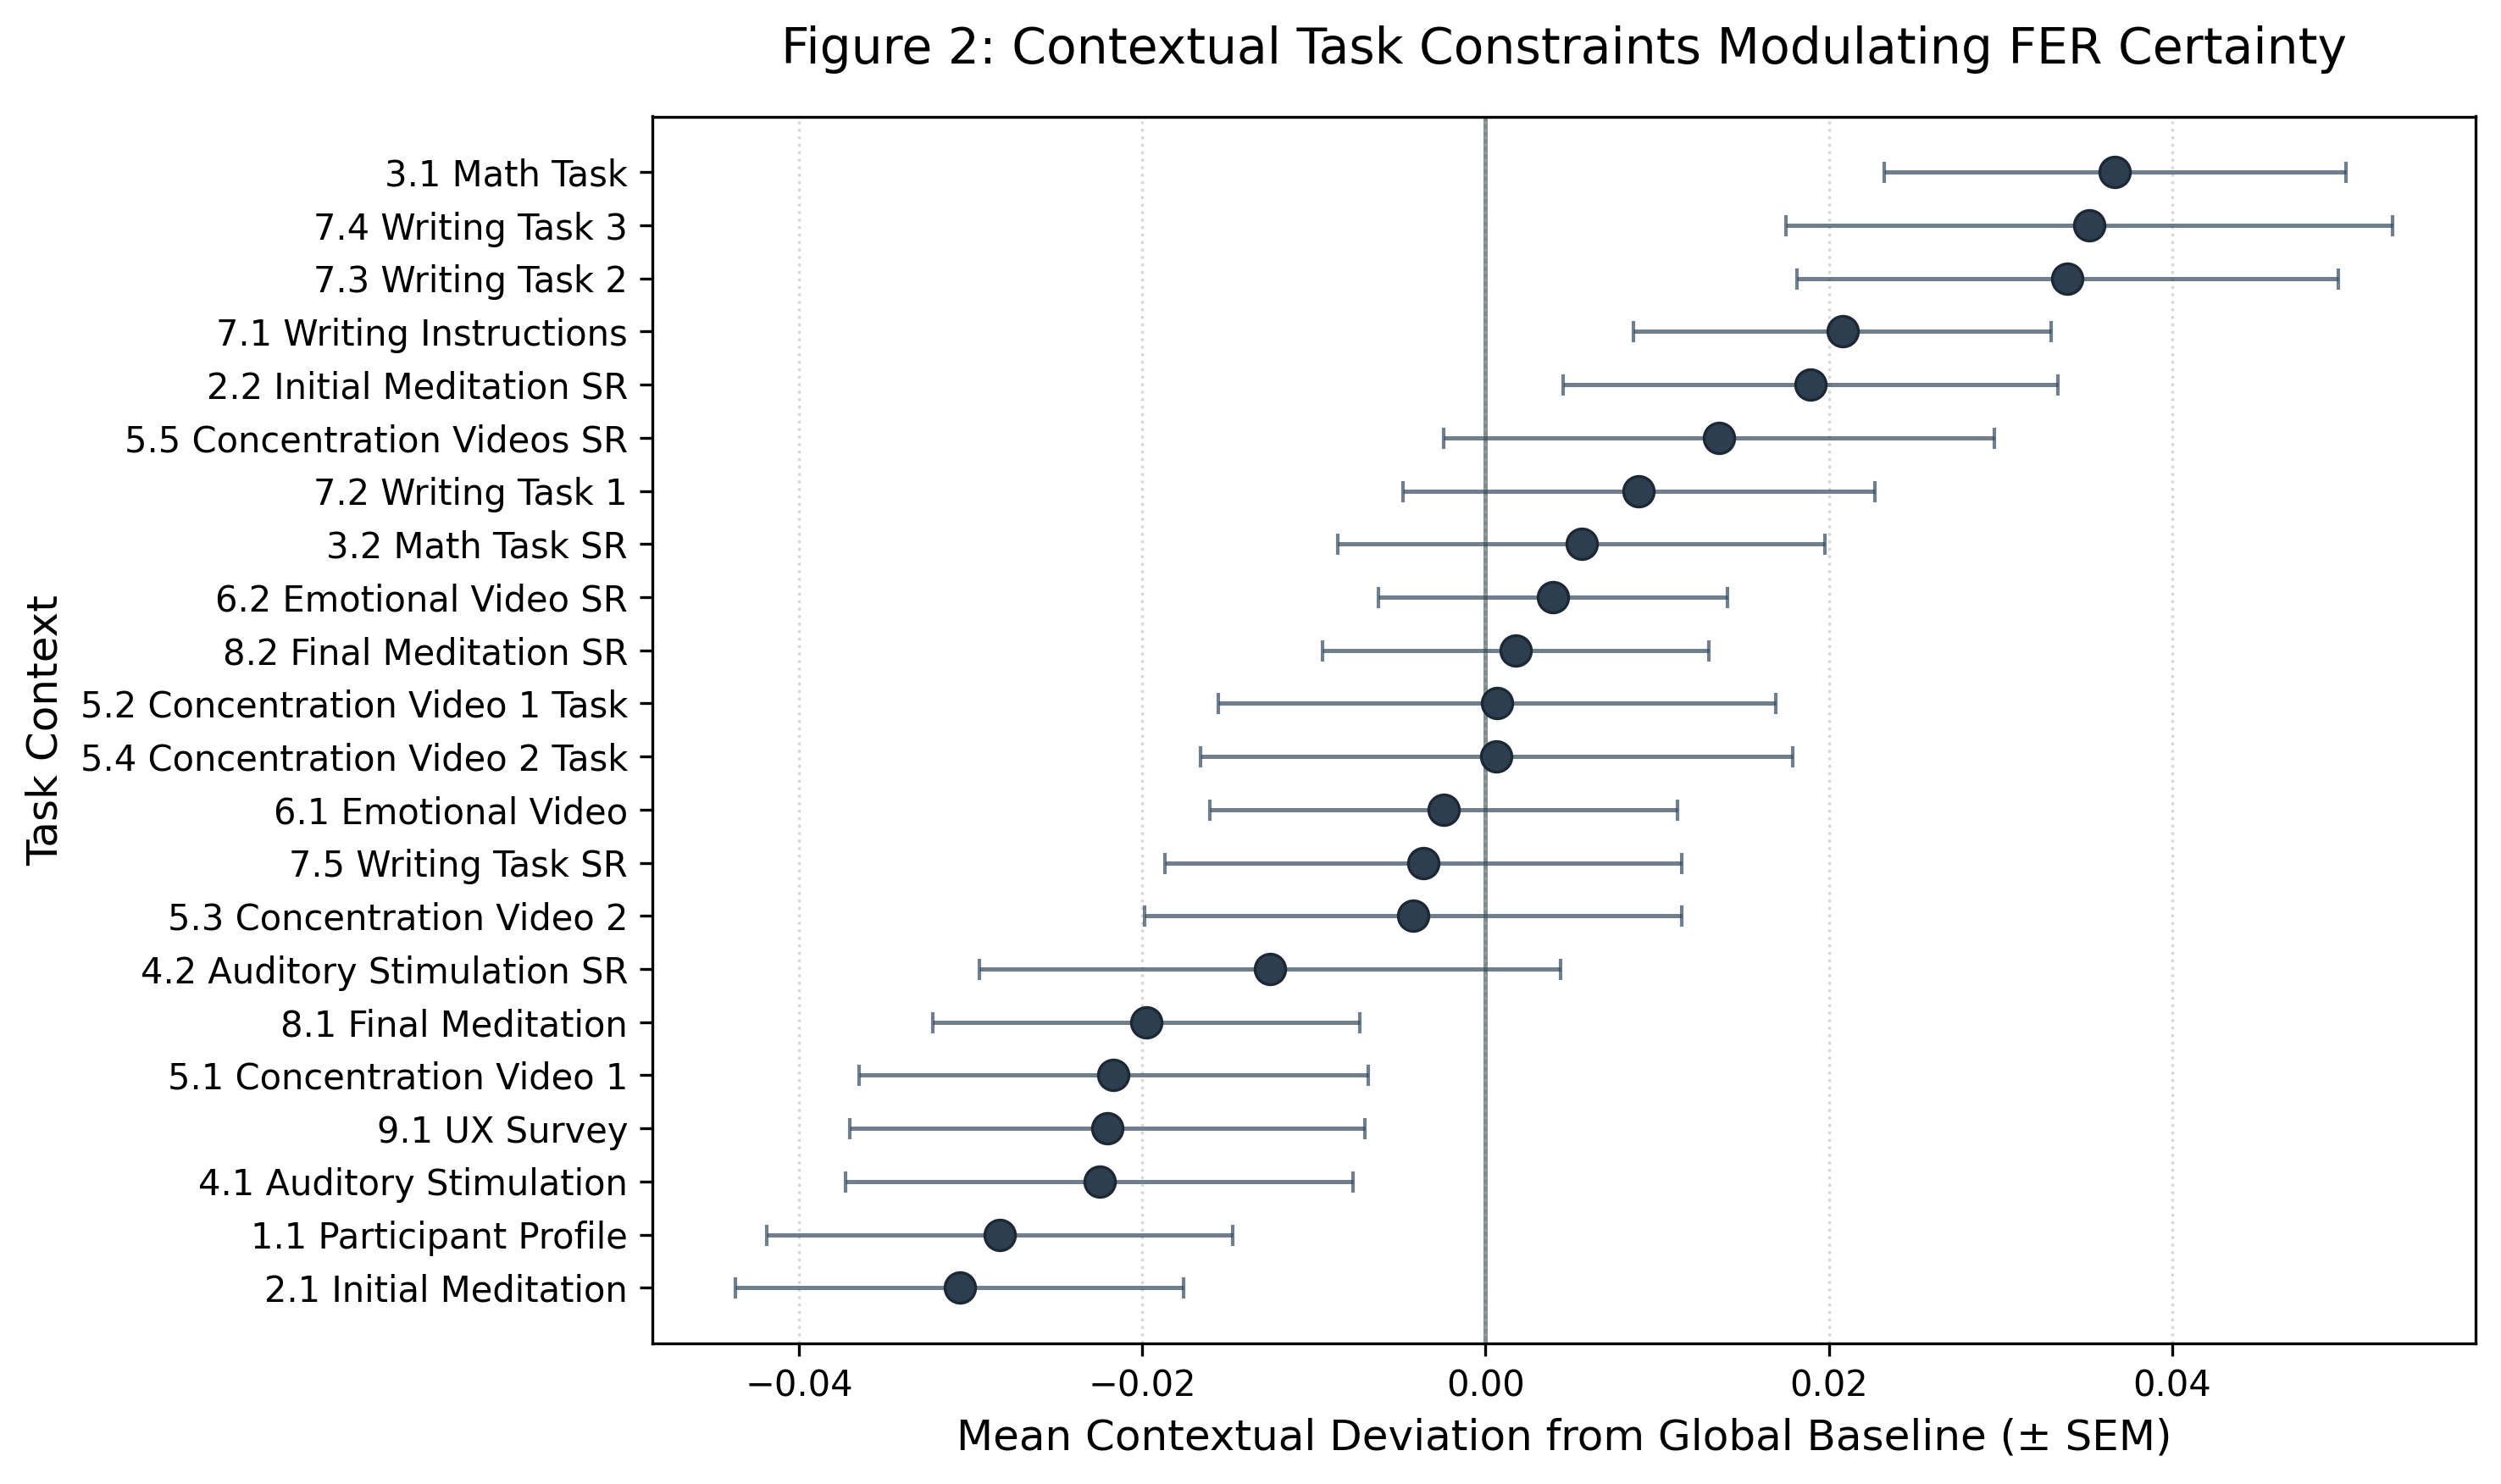

In [27]:
# ==========================================
# FIGURE 2: Caterpillar Plot for Task_Num
# ==========================================
import collections

TASK_LABEL_MAP = {
    "1.1": "1.1 Participant Profile",
    "2.1": "2.1 Initial Meditation",
    "2.2": "2.2 Initial Meditation SR",
    "3.1": "3.1 Math Task",
    "3.2": "3.2 Math Task SR",
    "4.1": "4.1 Auditory Stimulation",
    "4.2": "4.2 Auditory Stimulation SR",
    "5.1": "5.1 Concentration Video 1",
    "5.2": "5.2 Concentration Video 1 Task",
    "5.3": "5.3 Concentration Video 2",
    "5.4": "5.4 Concentration Video 2 Task",
    "5.5": "5.5 Concentration Videos SR",
    "6.1": "6.1 Emotional Video",
    "6.2": "6.2 Emotional Video SR",
    "7.1": "7.1 Writing Instructions",
    "7.2": "7.2 Writing Task 1",
    "7.3": "7.3 Writing Task 2",
    "7.4": "7.4 Writing Task 3",
    "7.5": "7.5 Writing Task SR",
    "8.1": "8.1 Final Meditation",
    "8.2": "8.2 Final Meditation SR",
    "9.1": "9.1 UX Survey",
}

re_dict = lmm_results.random_effects
task_raw_effects = collections.defaultdict(list)

for subject, effects in re_dict.items():
    for name, value in effects.items():
        if "task_num" in name:
            clean_name = name.split("[")[-1].replace("]", "").replace("T.", "")
            task_raw_effects[clean_name].append(value)

task_effects = {}
task_sems = {}
for clean_name, values in task_raw_effects.items():
    display_name = TASK_LABEL_MAP.get(clean_name, clean_name)
    task_effects[display_name] = np.mean(values)
    task_sems[display_name] = np.std(values, ddof=1) / np.sqrt(len(values))

task_df = pd.DataFrame(list(task_effects.items()), columns=["Task", "RandomEffect"])
task_df["SEM"] = task_df["Task"].map(task_sems)
task_df = task_df.sort_values(by="RandomEffect", ascending=True)

# Plot Initialization (Dimensions scale matching Panel B's aspect ratio layout)
fig, ax = plt.subplots(figsize=(10, 6))
y_pos_task = np.arange(len(task_df))

# 1. Solid vertical baseline anchor (Identical to Panel B)
ax.axvline(x=0, color="#7f8c8d", linestyle="-", linewidth=1.2, zorder=1)

# 2. Clean horizontal Standard Error intervals (Identical to Panel B)
ax.errorbar(
    task_df["RandomEffect"],
    y_pos_task,
    xerr=task_df["SEM"],
    fmt="none",
    ecolor="#34495e",
    capsize=3,
    elinewidth=1.2,
    alpha=0.7,
    zorder=2,
)

# 3. Standardized dark slate markers (Identical to Panel B)
ax.scatter(
    task_df["RandomEffect"],
    y_pos_task,
    color="#2c3e50",
    s=75,
    edgecolors="#1c2833",
    linewidths=0.8,
    zorder=3,
)

# Formatting
ax.set_yticks(y_pos_task)
ax.set_yticklabels(task_df["Task"])
ax.set_xlabel("Mean Contextual Deviation from Global Baseline (± SEM)")
ax.set_ylabel("Task Context")
ax.set_title("Figure 2: Contextual Task Constraints Modulating FER Certainty", pad=15)
ax.grid(axis="x", linestyle=":", alpha=0.5, zorder=0)

plt.tight_layout()
plt.savefig("figures/Fig2_Caterpillar_Task.png")
plt.show()
plt.close()

# Additional figures

These figures are not included in the main manuscript. However, they are included in the supplementary material.


## S2: Robustness Analysis Checks


### 1. RF Sensitivity to Scaling


In [ ]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

print("--- Robustness Check 1: Unscaled Random Forest ---")

# Unscaled RF (no preprocessing)
# assumes X_train, y_train, X_test, y_test are available
rf_unscaled = RandomForestRegressor(random_state=42, n_estimators=100, n_jobs=-1)
rf_unscaled.fit(X_train, y_train)

# predict
y_pred_unscaled = rf_unscaled.predict(X_test)

# metrics
mse_unscaled = mean_squared_error(y_test, y_pred_unscaled)
rmse_unscaled = np.sqrt(mse_unscaled)
mae_unscaled = mean_absolute_error(y_test, y_pred_unscaled)
r2_unscaled = r2_score(y_test, y_pred_unscaled)

n_rf = X_test.shape[0]
p_rf = X_test.shape[1]
adj_r2_unscaled = (
    1 - (1 - r2_unscaled) * (n_rf - 1) / (n_rf - p_rf - 1)
    if (n_rf - p_rf - 1) > 0
    else float("nan")
)

print("\n[Unscaled Model Performance Metrics]")
print(f"MSE: {mse_unscaled:.4f}")
print(f"RMSE: {rmse_unscaled:.4f}")
print(f"MAE: {mae_unscaled:.4f}")
print(f"R-squared: {r2_unscaled:.4f}")
print(f"Adjusted R-squared: {adj_r2_unscaled:.4f}\n")

unscaled_importances = pd.DataFrame(
    {"Feature": X_train.columns, "Importance": rf_unscaled.feature_importances_}
).sort_values(by="Importance", ascending=False)

unscaled_importances = unscaled_importances.reset_index(drop=True)
unscaled_importances.index += 1

print("[Full Unscaled Feature Importances]")
print(unscaled_importances.to_string())

--- Robustness Check 1: Unscaled Random Forest ---

[Unscaled Model Performance Metrics]
MSE: 0.0159
RMSE: 0.1261
MAE: 0.1013
R-squared: 0.4007
Adjusted R-squared: 0.3966

[Full Unscaled Feature Importances]
                Feature  Importance
1           EDA_aligned    0.105598
2   Temperature_aligned    0.103699
3             Gamma_AF8    0.066083
4           BVP_aligned    0.045649
5             Gamma_TP9    0.039850
6   Perceived_Tiredness    0.036923
7              Beta_AF7    0.036255
8            Gamma_TP10    0.035909
9             Alpha_TP9    0.032533
10             Beta_AF8    0.032368
11             Beta_TP9    0.032325
12           Alpha_TP10    0.032094
13            Beta_TP10    0.030960
14            Delta_TP9    0.029607
15            Theta_TP9    0.029122
16            Delta_AF7    0.028585
17           Theta_TP10    0.028014
18           Delta_TP10    0.027993
19            Gamma_AF7    0.027376
20            Delta_AF8    0.025814
21            Alpha_AF8    0.025727


### 2. LMM with 'Heavyweight' Exclusion

In unbalanced longitudinal datasets, mixed-effects models naturally assign more statistical weight to participants who provide higher volumes of uninterrupted data. To ensure that the fixed effects identified by the primary LMM were universally representative—and not disproportionately driven by a highly expressive minority—a "heavyweight" leave-out analysis was conducted.

Participants were sorted based on their relative statistical impact on the training set (i.e., the total number of valid frames contributed after hardware dropouts were excluded). The cohort was then filtered to systematically remove the top 10% of participants who contributed the absolute highest volume of clean data.

This 10% threshold was selected strategically:

- It rigorously stress-tests the model's resilience, proving the effects survive a systemic removal of high-fidelity data rather than just an isolated outlier.
- It avoids significantly reducing the degrees of freedom, preserving the statistical power required for the LMM to function effectively.


In [ ]:
import pandas as pd
import statsmodels.formula.api as smf

print("\n--- Robustness Check 2: LMM with 'Heavyweight' Exclusion ---")

# Identify high-contribution subjects
subject_contributions = train_lmm_df["Subject_ID"].value_counts()

print("Top 5 Participants with the Highest Data Contributions (Row Counts):")
print(subject_contributions.head(5))

# Select top ~10% contributors
heavyweight_subjects = subject_contributions.head(4).index.tolist()
print(f"\nSubjects flagged for exclusion (Top 10% volume): {heavyweight_subjects}")


--- Robustness Check 2: LMM with 'Heavyweight' Exclusion ---
Top 5 Participants with the Highest Data Contributions (Row Counts):
Subject_ID
IFE-EC-NPFC-T003-23    1233
IFE-EC-NPFC-T003-27    1091
IFE-EC-NPFC-T003-26    1090
IFE-EC-NPFC-T003-09    1049
IFE-EC-NPFC-T003-24    1016
Name: count, dtype: int64

Subjects flagged for exclusion (Top 10% volume): ['IFE-EC-NPFC-T003-23', 'IFE-EC-NPFC-T003-27', 'IFE-EC-NPFC-T003-26', 'IFE-EC-NPFC-T003-09']


In [ ]:
# Remove heavy contributors from training set
robust_train_lmm_df = train_lmm_df[
    ~train_lmm_df["Subject_ID"].isin(heavyweight_subjects)
]

print(f"Original LMM observations: {len(train_lmm_df)}")
print(f"Robust LMM observations (after exclusion): {len(robust_train_lmm_df)}\n")

# Refit the same LMM on filtered data
robust_lmm_model = smf.mixedlm(
    fixed_effects_formula,
    data=robust_train_lmm_df,
    groups=robust_train_lmm_df["Subject_ID"],
    vc_formula={"task_num": "0 + C(Task_Num)"},
)
robust_lmm_results = robust_lmm_model.fit()

# Output summary
print(robust_lmm_results.summary())

Original LMM observations: 21242
Robust LMM observations (after exclusion): 16779

                         Mixed Linear Model Regression Results
Model:                        MixedLM           Dependent Variable:           certainty
No. Observations:             16779             Method:                       REML     
No. Groups:                   34                Scale:                        0.0163   
Min. group size:              16                Log-Likelihood:               9899.1620
Max. group size:              1016              Converged:                    Yes      
Mean group size:              493.5                                                    
---------------------------------------------------------------------------------------
                                             Coef.  Std.Err.   z    P>|z| [0.025 0.975]
---------------------------------------------------------------------------------------
Intercept                                     0.695    0.014 4

/Users/sergiogzz/LocalDocs/GitHub/FER-Study/.venv/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


## S6. Figures and Tables


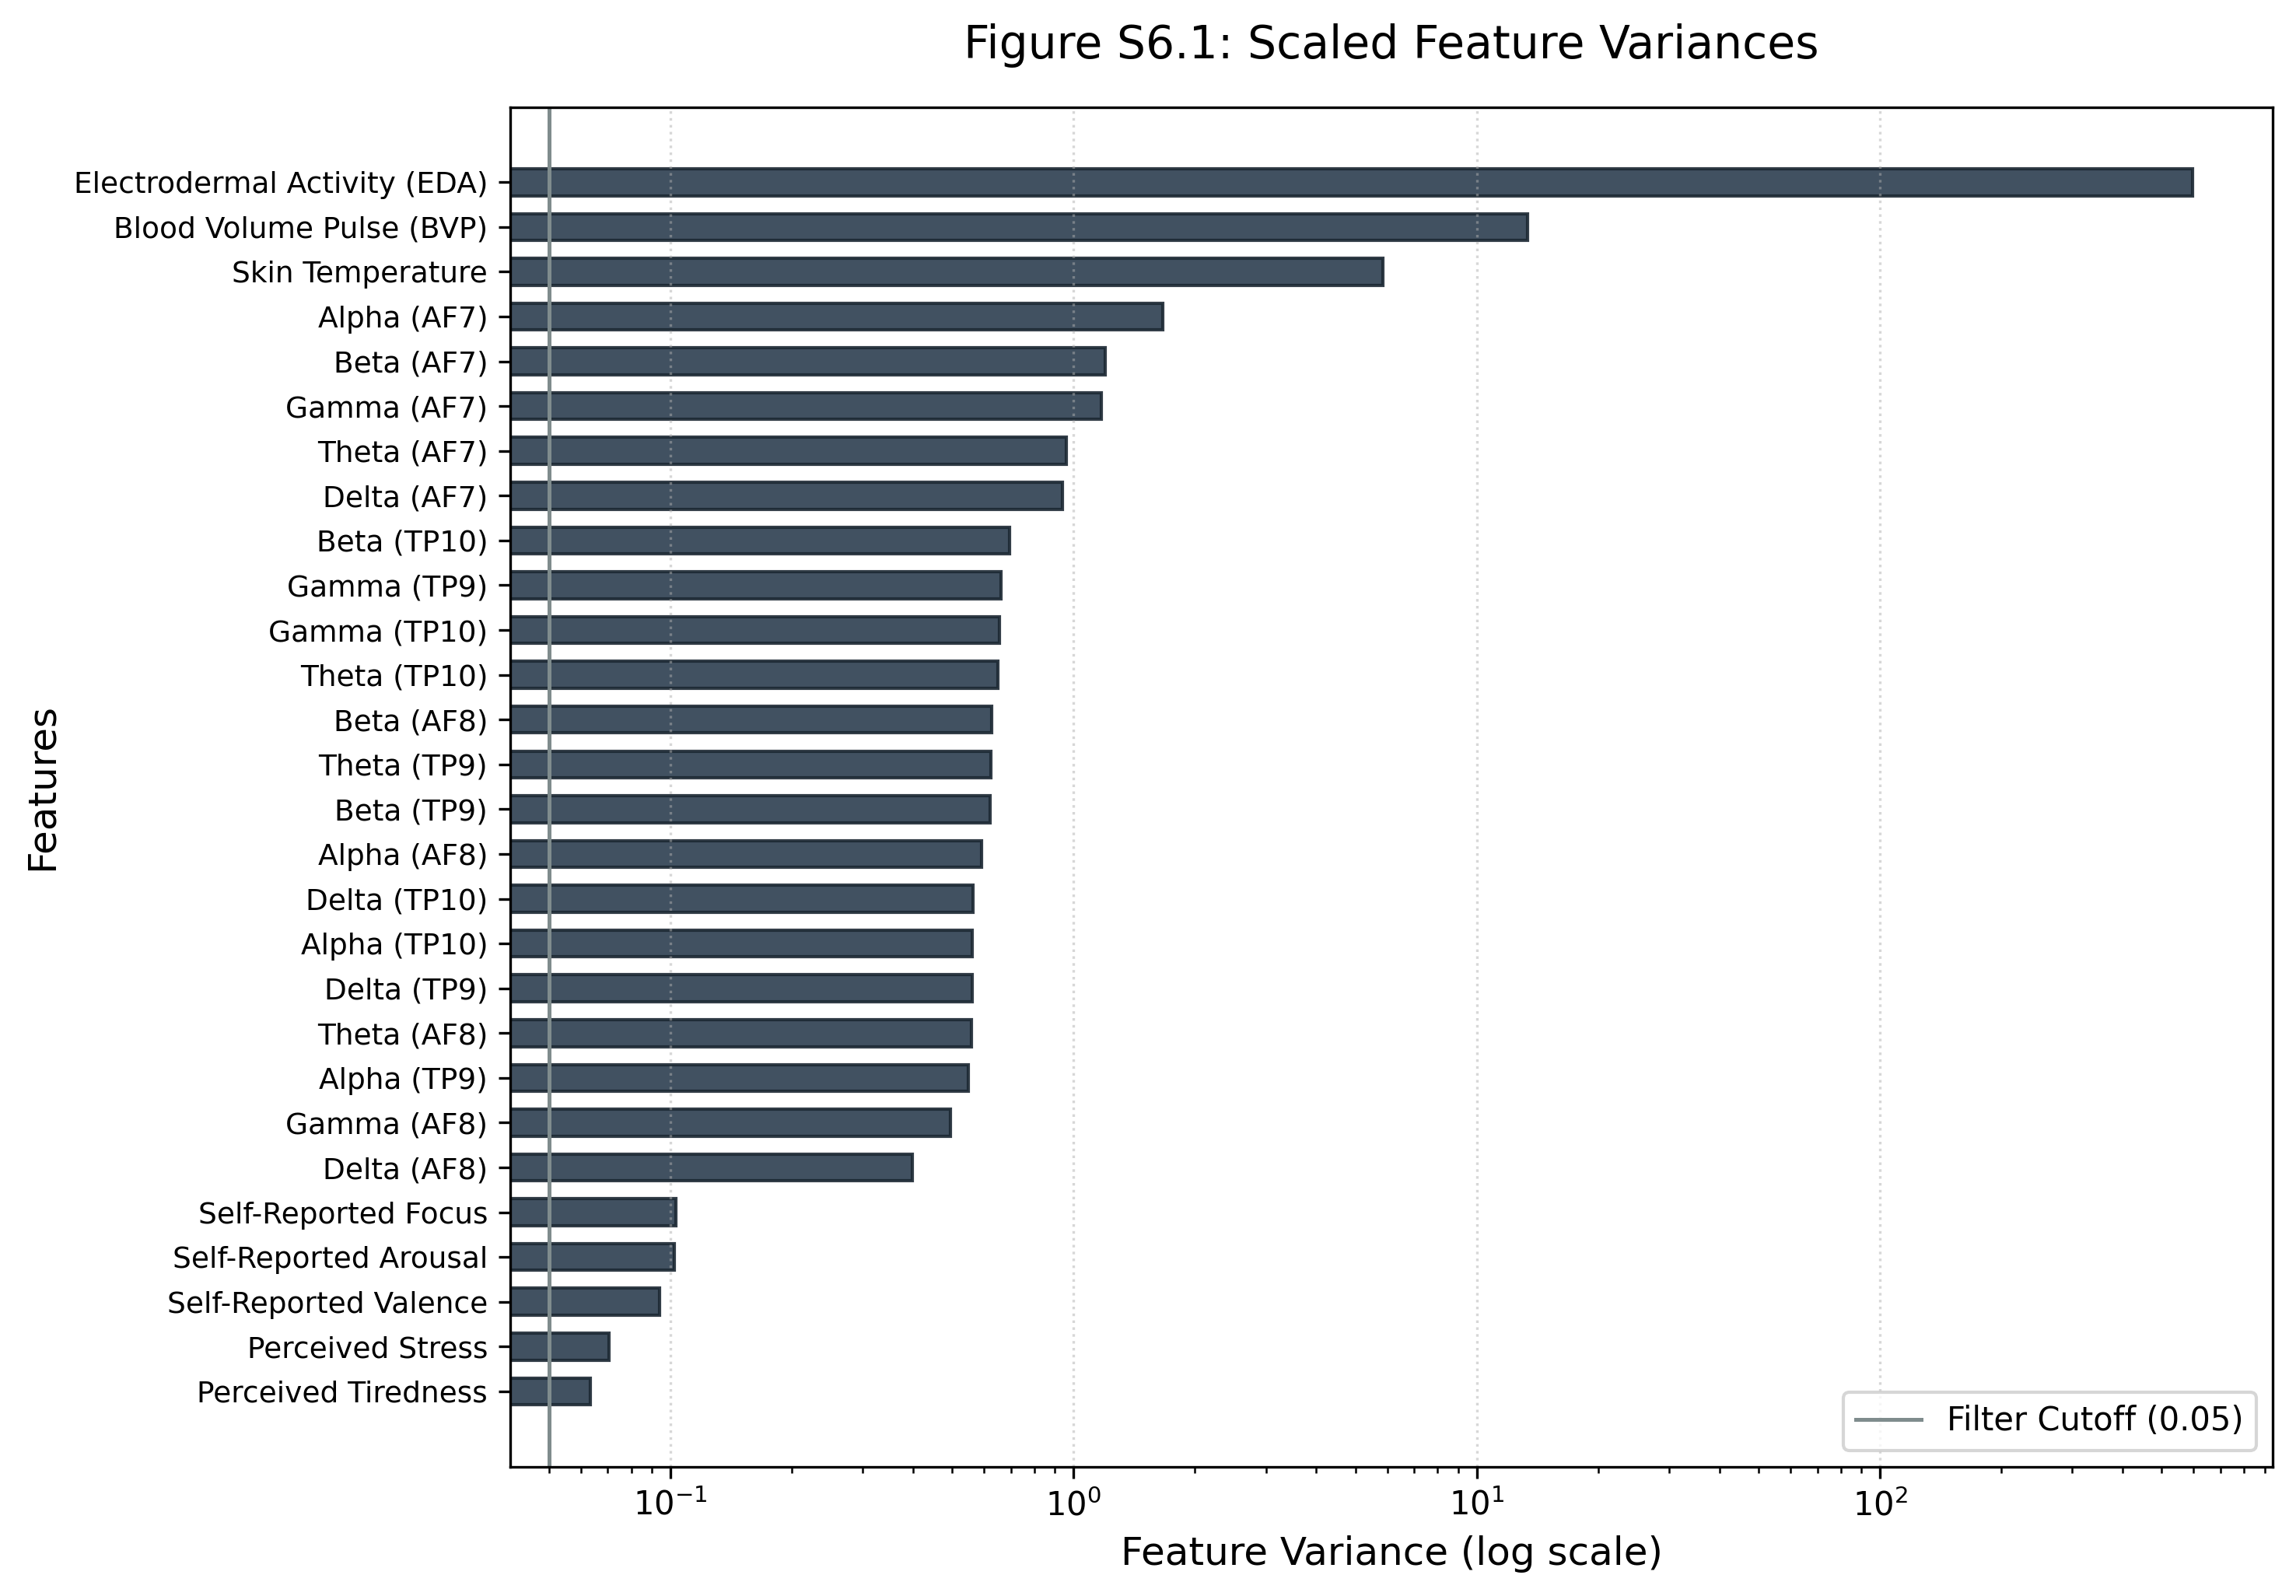

In [ ]:
# FIGURE S6.1: Scaled feature variances
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Compute variances for scaled training features
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=feature_names_out)
continuous_cols = [col for col in feature_names_out if "pass_binary" not in col]
scaled_variances = X_train_scaled_df[continuous_cols].var().sort_values(ascending=True)

# Human-friendly labels for a few known features
CLEAN_LABELS_MAP = {
    "Temperature": "Skin Temperature",
    "EDA": "Electrodermal Activity (EDA)",
    "BVP": "Blood Volume Pulse (BVP)",
    "Delta_TP9": "Delta (TP9)",
    "Delta_AF7": "Delta (AF7)",
    "Delta_AF8": "Delta (AF8)",
    "Delta_TP10": "Delta (TP10)",
    "Theta_TP9": "Theta (TP9)",
    "Theta_AF7": "Theta (AF7)",
    "Theta_AF8": "Theta (AF8)",
    "Theta_TP10": "Theta (TP10)",
    "Alpha_TP9": "Alpha (TP9)",
    "Alpha_AF7": "Alpha (AF7)",
    "Alpha_AF8": "Alpha (AF8)",
    "Alpha_TP10": "Alpha (TP10)",
    "Beta_TP9": "Beta (TP9)",
    "Beta_AF7": "Beta (AF7)",
    "Beta_AF8": "Beta (AF8)",
    "Beta_TP10": "Beta (TP10)",
    "Gamma_TP9": "Gamma (TP9)",
    "Gamma_AF7": "Gamma (AF7)",
    "Gamma_AF8": "Gamma (AF8)",
    "Gamma_TP10": "Gamma (TP10)",
    "Selfreport_valence": "Self-Reported Valence",
    "Selfreport_arousal": "Self-Reported Arousal",
    "Selfreport_focus": "Self-Reported Focus",
    "Perceived_Tiredness": "Perceived Tiredness",
    "Perceived_Stress": "Perceived Stress",
}


def format_feature_label(raw_name):
    # Strip Scikit-Learn pipeline prefixes and processing suffixes
    cleaned = (
        raw_name.replace("robust_sensors__", "")
        .replace("minmax_survey__", "")
        .replace("pass_binary__", "")
        .replace("_aligned", "")
    )
    return CLEAN_LABELS_MAP.get(cleaned, cleaned)


plot_variances = scaled_variances.copy()
plot_variances.index = plot_variances.index.map(format_feature_label)

# Plot
fig, ax = plt.subplots(figsize=(10, 7))
y_positions = range(len(plot_variances))
var_threshold = 0.05
ax.barh(
    y_positions,
    plot_variances.values,
    color="#2c3e50",
    alpha=0.9,
    edgecolor="#1c2833",
    height=0.6,
    log=True,
)
ax.axvline(
    x=var_threshold,
    color="#7f8c8d",
    linestyle="-",
    linewidth=1.2,
    label=f"Filter Cutoff ({var_threshold})",
)
ax.set_yticks(y_positions)
ax.set_yticklabels(plot_variances.index, fontsize=9)
ax.set_xlabel("Feature Variance (log scale)")
ax.set_ylabel("Features")
ax.set_title("Figure S6.1: Scaled Feature Variances", pad=15)
ax.grid(axis="x", linestyle=":", alpha=0.5)
ax.legend(loc="lower right")
plt.tight_layout()
plt.savefig("figures/FigS6_1_Feature_Variances.png", dpi=300)
plt.show()
plt.close()

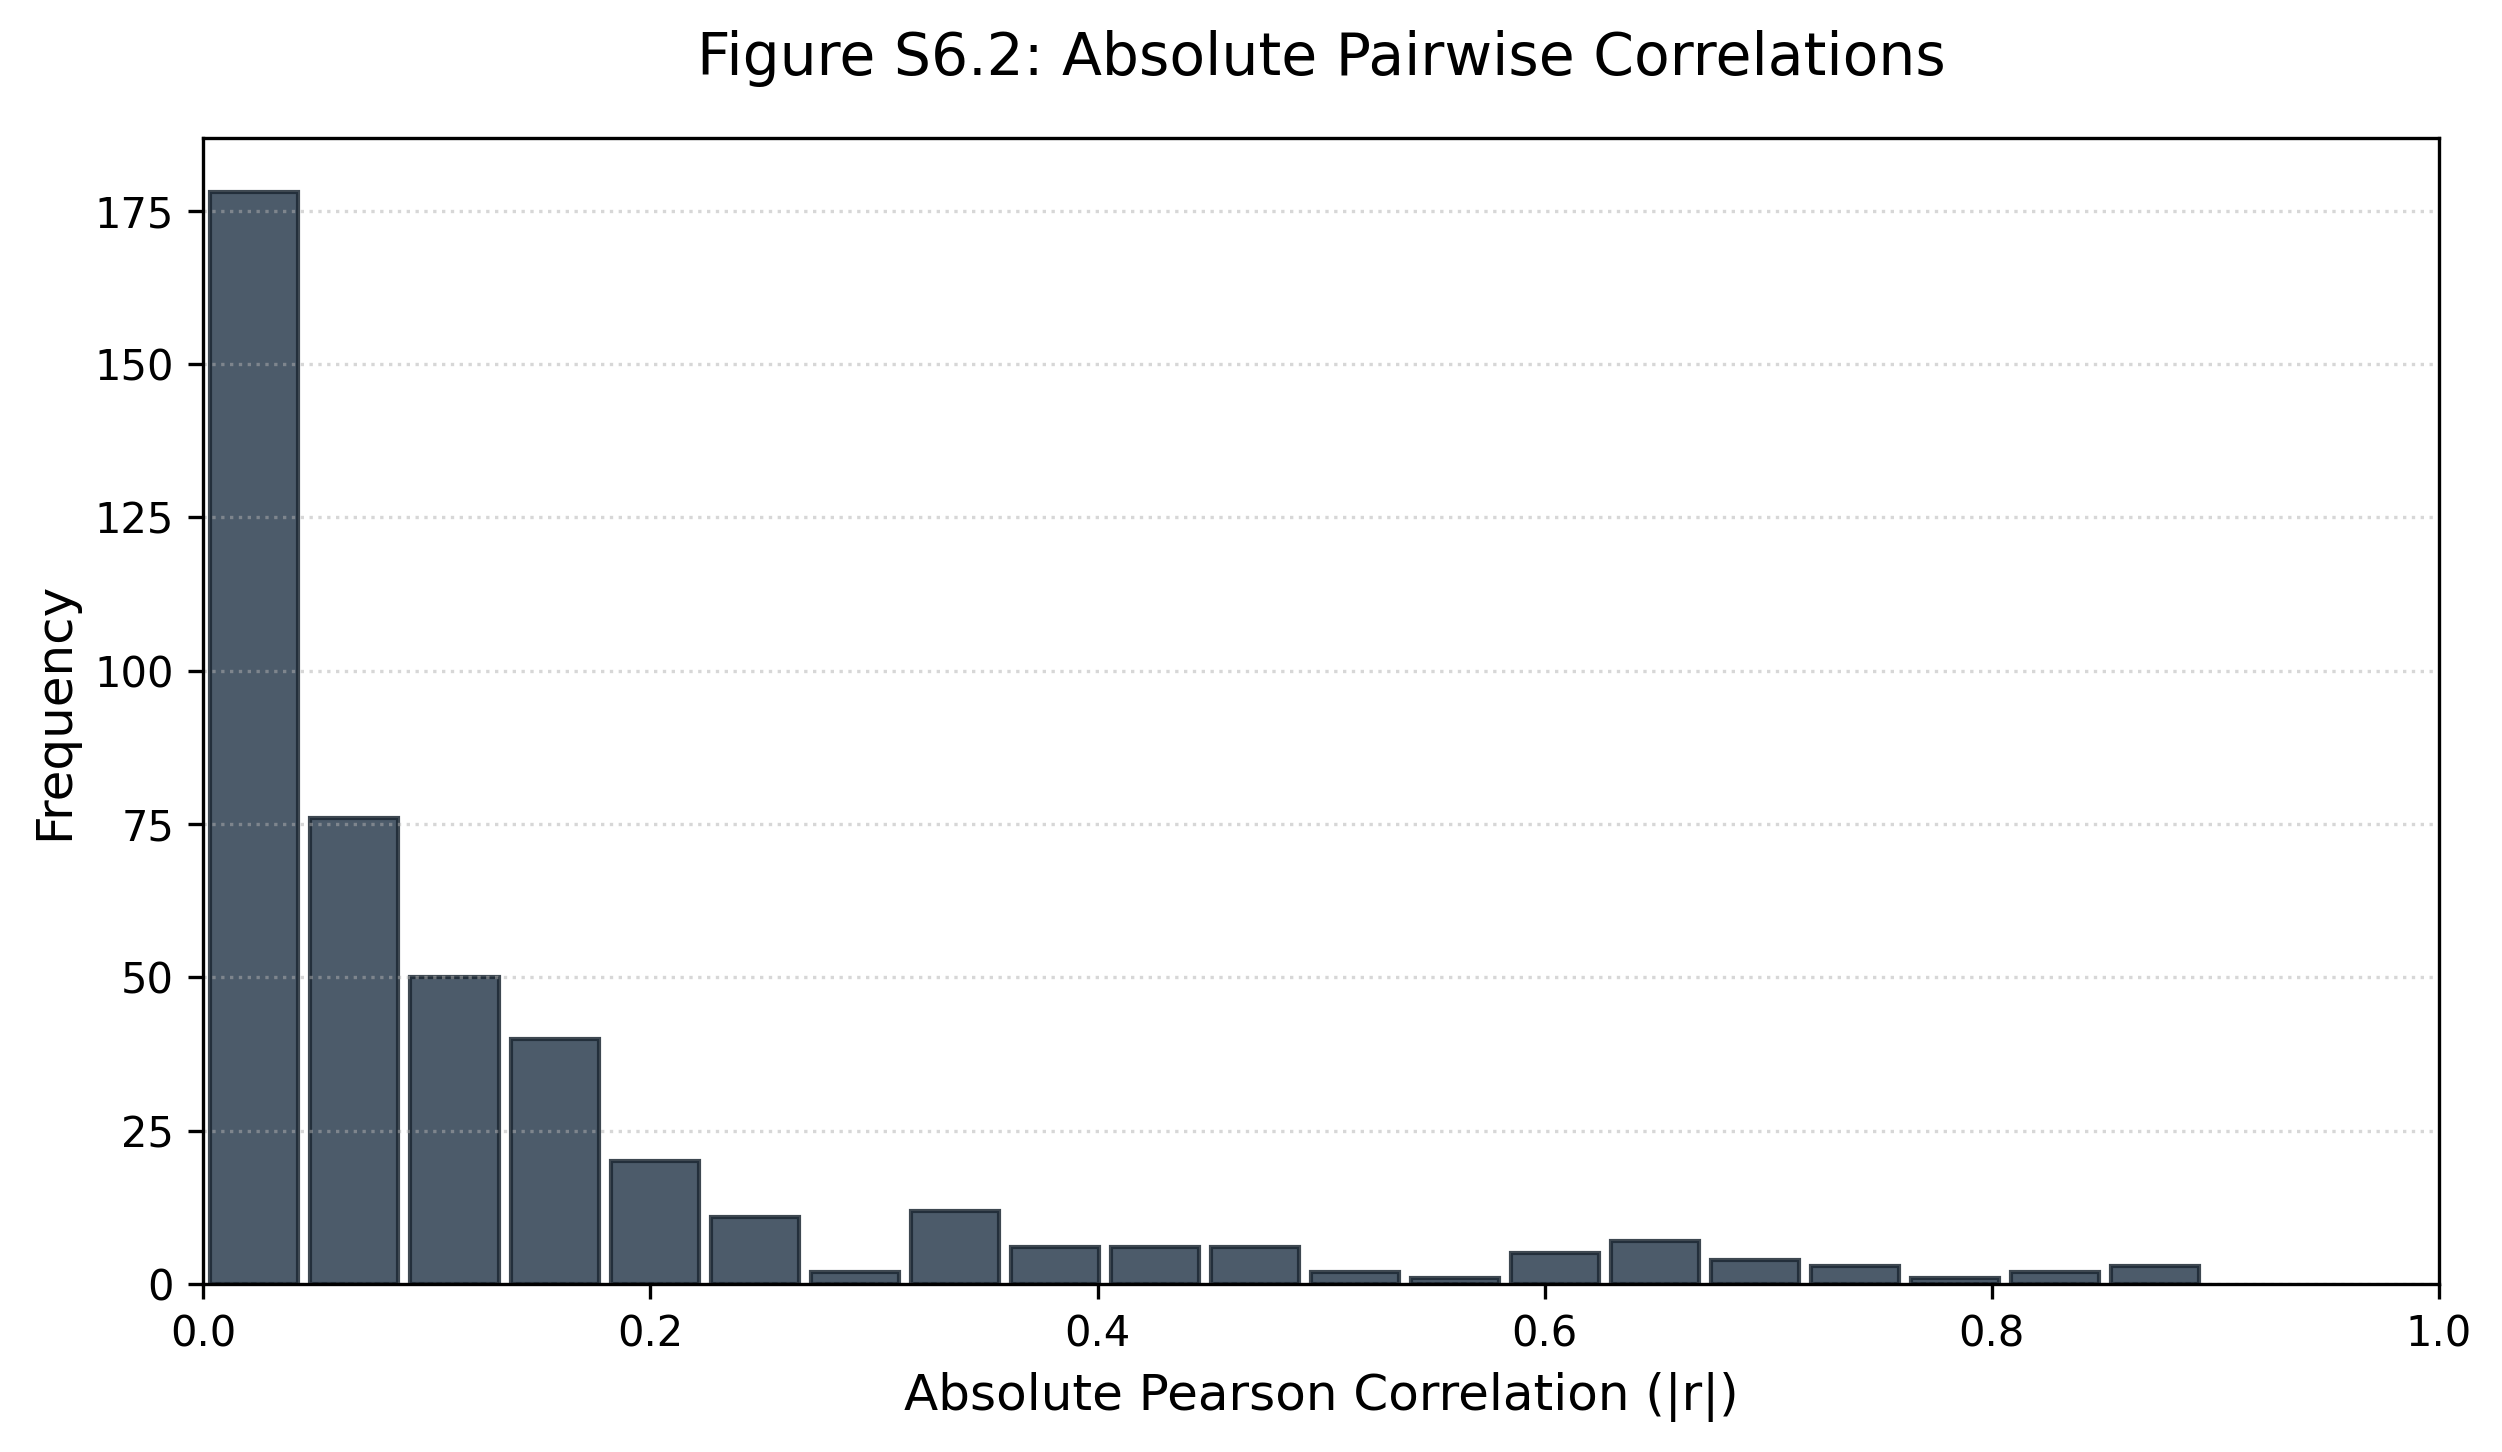

In [ ]:
# FIGURE S6.2: Distribution of absolute pairwise correlations
import matplotlib.pyplot as plt
import numpy as np

# Compute absolute pairwise correlations from scaled features
corr_matrix = X_train_scaled_df.corr().abs()
upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
corr_values = upper_tri.values.flatten()
corr_values = corr_values[~np.isnan(corr_values)]

# Plot
fig, ax = plt.subplots(figsize=(8.5, 5))
ax.hist(
    corr_values, bins=20, color="#2c3e50", alpha=0.85, edgecolor="#1c2833", rwidth=0.88
)
ax.set_title("Figure S6.2: Absolute Pairwise Correlations", pad=15)
ax.set_xlabel("Absolute Pearson Correlation (|r|)")
ax.set_ylabel("Frequency")
ax.grid(axis="y", linestyle=":", alpha=0.5)
ax.set_xlim(0, 1.0)
plt.tight_layout()
plt.savefig("figures/FigS6_2_Correlation_Histogram.png", dpi=300)
plt.show()
plt.close()

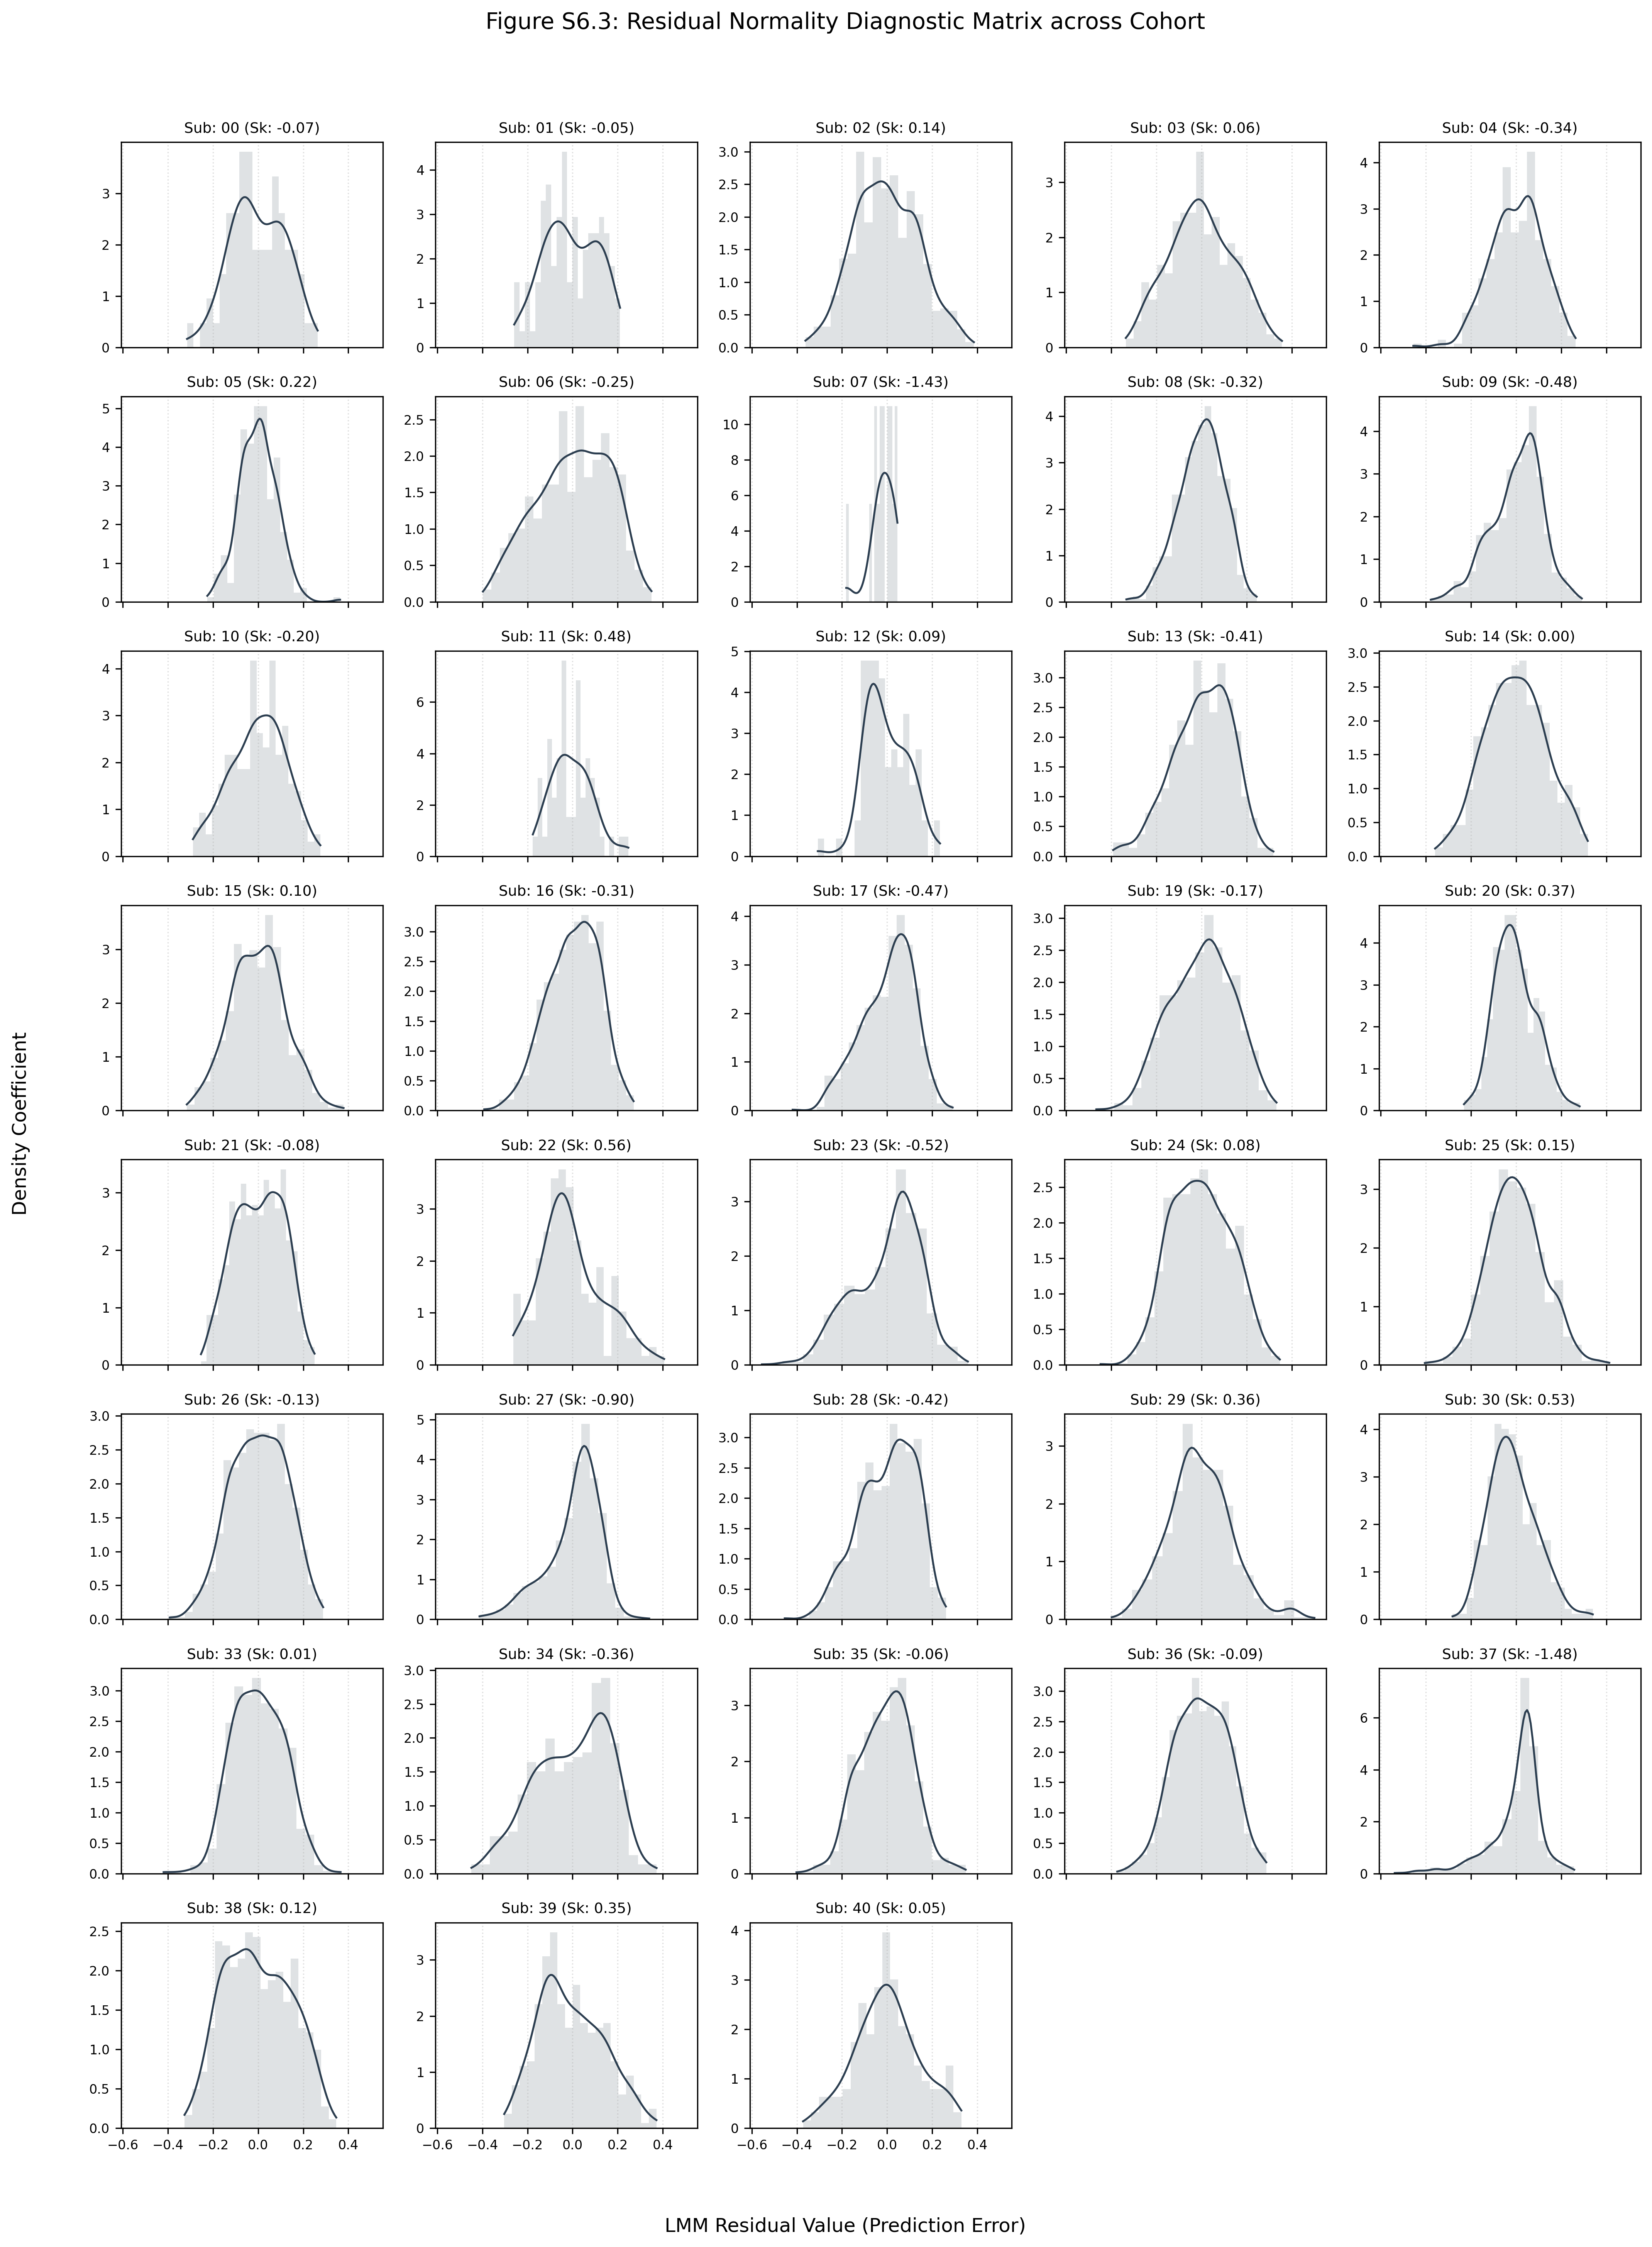

In [ ]:
# SUPPLEMENTARY FIG S6.3 — Residuals by subject
# Extract residuals and align with Subject IDs
lmm_df["Residuals"] = lmm_results.resid
unique_subjects = sorted(lmm_df["Subject_ID"].unique())
num_subjects = len(unique_subjects)

# Create an 8x5 grid for subject-level plots
fig, axes = plt.subplots(nrows=8, ncols=5, figsize=(15, 20), sharex=True)
axes_flat = axes.flatten()

for i, subject in enumerate(unique_subjects):
    ax = axes_flat[i]
    sub_res = lmm_df[lmm_df["Subject_ID"] == subject]["Residuals"].dropna()

    # Histogram of residuals
    ax.hist(sub_res, bins=20, density=True, color="#2c3e50", alpha=0.15)

    # Add KDE and compute skewness when there is enough data
    if len(sub_res) > 1:
        kde = stats.gaussian_kde(sub_res)
        x_range = np.linspace(sub_res.min(), sub_res.max(), 100)
        ax.plot(x_range, kde(x_range), color="#2c3e50", linewidth=1.2)
        sub_skew = stats.skew(sub_res)
    else:
        sub_skew = 0.0

    # Shorten subject id for readability and set subplot title
    clean_sub_id = subject.split("-")[-1] if "-" in subject else subject
    ax.set_title(f"Sub: {clean_sub_id} (Sk: {sub_skew:.2f})", fontsize=9)
    ax.grid(axis="x", linestyle=":", alpha=0.4)
    ax.tick_params(axis="both", labelsize=8)

# Remove unused axes in the grid
for j in range(num_subjects, len(axes_flat)):
    fig.delaxes(axes_flat[j])

# 4. Global figure structural adjustments
fig.supxlabel("LMM Residual Value (Prediction Error)", fontsize=12, y=0.02)
fig.supylabel("Density Coefficient", fontsize=12, x=0.02)
fig.suptitle(
    "Figure S6.3: Residual Normality Diagnostic Matrix across Cohort",
    fontsize=14,
    y=0.98,
)

plt.tight_layout(rect=[0.03, 0.03, 0.97, 0.96])
plt.savefig("figures/FigS6_3_Residual_Grid.png", dpi=300)
plt.show()
plt.close()